# <span style="color:rgb(213,80,0)">Classical Narrowband DOA Estimation Methods</span>
This code aims at reviewing some classical DOA estimation algorithms for narrowband array signal processing. It includes 3 parts: Beamforming\-based Methods, Subspace Methods and Parametric Methods.


For far\-feild narrowband signal model, the scale of array is small enough that the complex envelop of impinging signals can be regarded as invariant for different elements, which means the phase\-shift caused by spatial interval of array elements is a constant with respect to different frequncy components of the signal. So the steering vector is only dependent on DOA $\theta$ (we only consider linear array here, in fact it depends on elevation $\phi$ and azimuth $\theta$ ).  So the signal model can be written as


 $\mathbf{x}(t) = \mathbf{A}\mathbf{s}(t)+\mathbf{n}$ , $\mathbf{A}=\begin{bmatrix}\mathbf{a}(\theta_1)&\mathbf{a}(\theta_2)&\cdots&\mathbf{a}(\theta_K)\end{bmatrix}$ , $\mathbf{a}(\theta_k)=\begin{bmatrix}1&e^{-j\frac{2\pi d}{\lambda}\sin(\theta_k)}&\cdots&e^{-j\frac{2\pi(M-1)d}{\lambda}\sin(\theta_k)}\end{bmatrix}^{T}$ , $\mathbf{s}(t)=\begin{bmatrix}s_1(t)&s_2(t)&\cdots&s_K(t)\end{bmatrix}^{T}$ where $d$ and $M$ denotes the spatial interval of array elements and number of elements. For a typical uniform linear array(ULA), $d = \frac{\lambda}{2}$ .


In [ ]:
num_sources = 7;
M = 12;
d = 0.5; % normalized spatial interval
position = (0:M-1).'*d;
theta = [-25.1,-19.3,11.7,15.5,30.6,37.2,66.8]; % DOA of sources
num_snapshots = 512; %number of snapshots
SNR = 10;
steering_vector = @(theta) ...
    exp(-1j*2*pi * position * sind(theta));
% S = randn(num_sources,num_snapshots)+1j*randn(num_sources,num_snapshots);
S = randn(num_sources,num_snapshots);
A = steering_vector(theta);
% A*A'
X = A*S;
X = awgn(X,SNR,'measured');
R_xx = X*X'/num_snapshots;

## Part I: Beamforming Based methods
### Conventional Beamformer

Beamforming is often used for spatial filtering. But one direct idea is that if SNR is high enough, we can let the beamformer scan the whole angle domain, the output power will indicate the doa of signals. Conventional beamforming, or the delay\-and\-sum beamformer sets the weight vector equal to steering vector, i.e. $\mathbf{w} = \mathbf{a}(\theta)$ . So the output power of signal is




$$
\begin{aligned}
P_y
&=\mathbb{E}\!\left\{|y(t)|^2\right\}\\
&=\mathbf{w}^{H}\mathbb{E}\!\left\{\mathbf{x}(t)\mathbf{x}^{H}(t)\right\}\mathbf{w}\\
&=\mathbf{w}^{H}\mathbf{R}_{xx}\mathbf{w}
\end{aligned}
$$



the covaraince matrix can be estimated by the second\-order moment of $\mathbf{x}(t)$ , i.e. $\hat{\mathbf{R}}_{xx}=\frac{1}{N}\mathbf{X}\mathbf{X}^{H}$ . Because $\mathbf{w} = \mathbf{a}(\theta)$ ,


 $P_{\mathrm{CBF}}(\theta)=\mathbf{a}^{H}(\theta)\mathbf{R}_{xx}\mathbf{a}(\theta)$ . This is called Bartlett Spectrum.


Bartlett estimated angles (degrees):
  -57.7000  -42.1000  -22.1000   -1.3000   13.5000   33.5000   66.6000

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

Bartlett RMSE = 21.756510 degrees


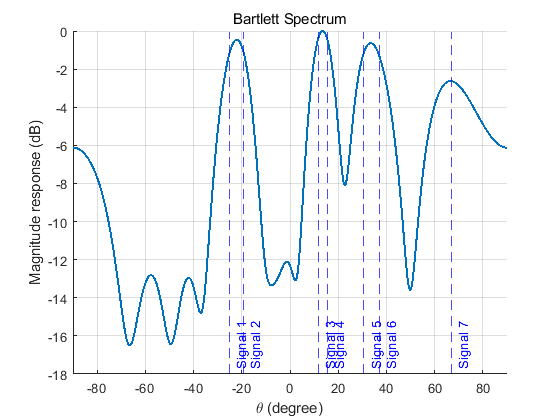

In [ ]:
theta_plot = -90:0.1:89.9;
P_CBF = zeros([length(theta_plot),1]);
for i = 1:length(theta_plot)
    w = steering_vector(theta_plot(i));
    P_CBF(i) = real(w'*R_xx*w);
end

P_CBF = 10*log10(P_CBF/(max(P_CBF)));
[~, Bartlett_DOA] = findpeaks(P_CBF(:).', theta_plot, ...
    'SortStr', 'descend', 'NPeaks', num_sources, ...
    'MinPeakDistance', 1);
Bartlett_DOA = sort(Bartlett_DOA(:).');
if numel(Bartlett_DOA) == num_sources
    rmse_bartlett = sqrt(mean((Bartlett_DOA - sort(theta(:).')).^2));
else
    rmse_bartlett = NaN;
    warning('Bartlett:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', numel(Bartlett_DOA));
end
fprintf('Bartlett estimated angles (degrees):\n');
disp(Bartlett_DOA);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('Bartlett RMSE = %.6f degrees\n', rmse_bartlett);
figure;
hold on;
h_bartlett = plot(theta_plot, P_CBF, 'LineWidth', 1.5);

grid on;
xlim([-90 90]);
% ylim([-80 0]);

h_sig = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Bartlett Spectrum');


However, conventional beamforming method is limited to the scale of array, which is often called as  *Rayleigh limit.* Usually, the main lobe would be too wide to distinguish doa of different signals from each other. However, it is computionally efficient, because it doesn't contain matrix inversion or eigendecomposition.

### Capon Spatial Spectral Estimation

Capon beamforming, or MVDR beamforming is also a wide\-used method for DOA estimation. The concept and specific form of Capon spectrum has been detailly listed in the narrowband beamformer simulation codes. The for of Capon spectrum is


 $P_{\mathrm{Capon}}(\theta)=\frac{1}{\mathbf{a}^{H}(\theta)\mathbf{R}_{xx}^{-1}\mathbf{a}(\theta)}$ . Usually, Capon spectrum has a better spatial resolution than Bartlett spectrum


Capon estimated angles (degrees):
  -24.9000  -19.4000   -3.8000   13.5000   31.0000   37.0000   66.8000

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

Capon RMSE = 5.910040 degrees


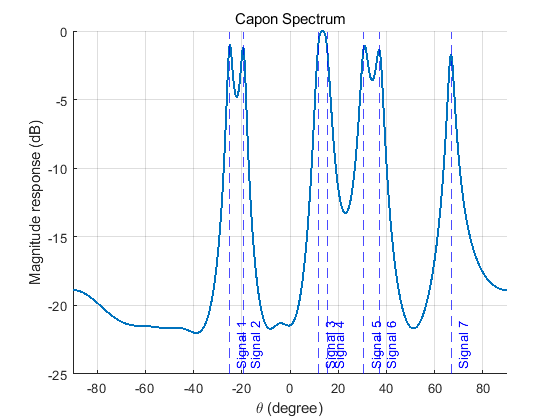

In [68]:
R_xx_inv = inv(R_xx);
P_Capon = zeros([length(theta_plot),1]);
for i = 1:length(theta_plot)
    a = steering_vector(theta_plot(i));
    P_Capon(i) = 1/abs(a'*R_xx_inv*a);
end

P_Capon = 10*log10(P_Capon/(max(P_Capon)));
[~, Capon_DOA] = findpeaks(P_Capon(:).', theta_plot, ...
    'SortStr', 'descend', 'NPeaks', num_sources, ...
    'MinPeakDistance', 1);
Capon_DOA = sort(Capon_DOA(:).');
if numel(Capon_DOA) == num_sources
    rmse_capon = sqrt(mean((Capon_DOA - sort(theta(:).')).^2));
else
    rmse_capon = NaN;
    warning('Capon:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', numel(Capon_DOA));
end
fprintf('Capon estimated angles (degrees):\n');
disp(Capon_DOA);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('Capon RMSE = %.6f degrees\n', rmse_capon);
figure;
hold on;
h_Capon = plot(theta_plot, P_Capon, 'LineWidth', 1.5);

grid on;
xlim([-90 90]);
% ylim([-80 0]);

h_sig = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('Capon Spectrum');

### FFT DOA Estimation
Ignore the noise and consider only one snapshot. The received signal is $\mathbf{x}=\mathbf{A}s$. Consistent with the steering-vector convention used above, for a single source, $x_m=s e^{-j2\pi(m-1)\frac{d}{\lambda}\sin\theta_k}$. Define the normalized spatial angular frequency $\omega_k=2\pi\frac{d}{\lambda}\sin\theta_k$, so that $x_m=s e^{-j(m-1)\omega_k}$. Applying the FFT to the received signal gives

$$
\begin{aligned}
X(\omega) &= \sum_{m=1}^{M} x_m e^{-j(m-1)\omega} \\
&= \sum_{m=1}^{M} s e^{-j(m-1)\omega_k} e^{-j(m-1)\omega} \\
&= s \sum_{m=1}^{M} e^{-j(m-1)(\omega_k+\omega)} \\
&= s \frac{1-e^{-jM(\omega_k+\omega)}}{1-e^{-j(\omega_k+\omega)}}.
\end{aligned}
$$

Thus, on the centered unaliased spatial-frequency interval, the FFT peak occurs at $\omega=-\omega_k$. Therefore, the DOA corresponding to an FFT bin $\omega$ is

$$
\theta=\arcsin\!\left(-\frac{\lambda\omega}{2\pi d}\right).
$$

FFT estimated angles (degrees):
  -57.7473  -42.0610  -22.0243   -1.3430   13.5548   33.4206   66.6309

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

FFT RMSE = 21.744561 degrees


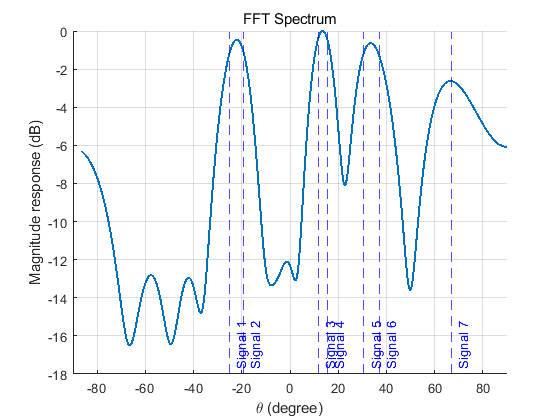

In [69]:
N_fft = 1024;
X_omega = fftshift(fft(X, N_fft, 1), 1);
P_FFT = mean(abs(X_omega).^2, 2);

% Exact centered FFT-bin grid. Here d is normalized by wavelength.
omega_fft = (-N_fft/2:N_fft/2-1).' * (2*pi/N_fft);
valid_fft = abs(omega_fft) <= 2*pi*d;
omega_fft = omega_fft(valid_fft);
P_FFT = P_FFT(valid_fft);

% The minus sign follows from a(theta) = exp(-1j*m*omega).
theta_fft = -asind(omega_fft/(2*pi*d));
[theta_fft, fft_order] = sort(theta_fft);
P_FFT = P_FFT(fft_order);
P_FFT = 10*log10(max(P_FFT, eps)/max(P_FFT));

[~, FFT_DOA] = findpeaks(P_FFT(:).', theta_fft(:).', ...
    'SortStr', 'descend', 'NPeaks', num_sources, ...
    'MinPeakDistance', 1);
FFT_DOA = sort(FFT_DOA(:).');
true_DOA = sort(theta(:).');
if numel(FFT_DOA) == num_sources
    rmse_fft = sqrt(mean((FFT_DOA - true_DOA).^2));
else
    rmse_fft = NaN;
    warning('FFT:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', numel(FFT_DOA));
end
fprintf('FFT estimated angles (degrees):\n');
disp(FFT_DOA);
fprintf('True angles (degrees):\n');
disp(true_DOA);
fprintf('FFT RMSE = %.6f degrees\n', rmse_fft);
figure;
hold on;
h_FFT = plot(theta_fft, P_FFT, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
% ylim([-80 0]);

h_sig = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('FFT Spectrum');

## Part II: Subspace Methods
### MUSIC

Theoretically, The covaraiance matrix $\mathbf{R}_{xx}$ is a postive Hermitian Toeplitz matrix. When we substitute $\mathbf{R}_{xx}$ by $\hat{\mathbf{R}}_{xx}$ , although $\hat{\mathbf{R}}_{xx}$ is not a Toeplitz matrix, it's still an Hermitian matrix. According to the properties of Hermitian matrix. We have $\mathbf{R}_{xx}=\mathbf{U}\boldsymbol{\Lambda}\mathbf{U}^{H}$ , where $\mathbf{U}$ is a unitary matrix, $\boldsymbol{\Lambda}$ is a diagonal matrix whose diagonal line is consist of the eigenvalue of $\mathbf{R}_{xx}$ . And according to the properties of unitary matrix and Hermitian matrix, we can deduce that: 1. The eigenvectors of covaraince matirx $\mathbf{R}_{xx}$ are orthogonal to each other. 2. The eigenvalues of $\mathbf{R}_{xx}$ are real. Those are the foundation of subspace methods, beacuse it indicates that the signal subspace and noise subspace are orthogonal to each other.


For uncorrelated signals and white noise, we can decompose $\mathbf{R}_{xx}$ as $\mathbf{R}_{xx}=\mathbf{A}\mathbf{R}_{s}\mathbf{A}^{H}+\sigma^{2}\mathbf{I}=\mathbf{R}_{\mathrm{sig}}+\sigma^{2}\mathbf{I}$ , where $\mathbf{R}_{s}=\operatorname{diag}(P_1,P_2,\ldots,P_K)$ . Suppose the number of sources is less than the number of elements, i.e. $K<M$ , so for $\mathbf{R}_{\mathrm{sig}}\in\mathbb{C}^{M\times M}$ , $\operatorname{rank}(\mathbf{R}_{\mathrm{sig}})=K$ , which means its eigenvalue matrix is $\boldsymbol{\Lambda}_{\mathrm{sig}}=\operatorname{diag}(\lambda_1,\lambda_2,\ldots,\lambda_K,0,\ldots,0)$ . Applying eigendecompostion to $\mathbf{R}_{\mathrm{sig}}$ , we obtain


 

$$
\begin{aligned}
\mathbf{R}_{\mathrm{sig}}
&=\mathbf{U}\boldsymbol{\Lambda}_{\mathrm{sig}}\mathbf{U}^{H}\\
&=\begin{bmatrix}\mathbf{U}_s&\mathbf{U}_n\end{bmatrix}
\begin{bmatrix}\boldsymbol{\Lambda}_s&\mathbf{0}\\\mathbf{0}&\mathbf{0}\end{bmatrix}
\begin{bmatrix}\mathbf{U}_s&\mathbf{U}_n\end{bmatrix}^{H}
\end{aligned}
$$

 .


Before we continue, we may as well consider the relationship between eigenvector, eigenvalue and steering vector, signal power.


Consider the simplest scenario where we only have 1 impinging signal. Then $\mathbf{R}_{\mathrm{sig}}=p_s\mathbf{a}(\theta)\mathbf{a}^{H}(\theta)$ . So the rank of signal subspace is 1, which means we only have one eigenvector and one eignevalue indicate signal subspace. Thus, according to the definition of eigenvalue, we have


 

$$
\begin{aligned}
\mathbf{R}_{\mathrm{sig}}\mathbf{u}_s&=\lambda\mathbf{u}_s,\\
p_s\mathbf{a}(\theta)\mathbf{a}^{H}(\theta)\mathbf{u}_s&=\lambda\mathbf{u}_s
\end{aligned}
$$

 . Because $\lambda \neq0$ , then $\mathbf{u}_s\in\operatorname{col}(\mathbf{A})$ . While , $\operatorname{rank}(\mathbf{A})=1$ , $\mathbf{u}_s =\alpha \mathbf{a}$ . Let $\mathbf{u}_s=\frac{\mathbf{a}}{\lVert\mathbf{a}\rVert_2}$ , because the  then


 $p_s\mathbf{a}\mathbf{a}^{H}\frac{\mathbf{a}}{\lVert\mathbf{a}\rVert_2}=\lambda\frac{\mathbf{a}}{\lVert\mathbf{a}\rVert_2}$ , we get $\lambda=p_s\lVert\mathbf{a}\rVert_2^{2}$ . So eigenvalue is the scale of signal power, eigenvector fall into the column space of array manifold matrix $\mathbf{A}$ , i.e. $\operatorname{span}(\mathbf{U}_s)=\operatorname{span}(\mathbf{A})$ .


If we consider multiple impinging signal scenario, the conclusion is the same. So the non\-zero eigenvalues of $\mathbf{R}_{sig}$ can indicate the scale of signal power, corresponding eigenvectors can indicate the signal subspace.


Then consider the noise space and corresponing eigenvector.




$$
\begin{aligned}
\mathbf{u}_n^{H}\mathbf{A}\mathbf{R}_s\mathbf{A}^{H}\mathbf{u}_n&=0,\\
(\mathbf{A}^{H}\mathbf{u}_n)^{H}\mathbf{R}_s(\mathbf{A}^{H}\mathbf{u}_n)&=0
\end{aligned}
$$



Because $\mathbf{R}_s\succ\mathbf{0}$ , Then $\operatorname{span}(\mathbf{U}_n)=\operatorname{null}(\mathbf{A}^{H})=\operatorname{span}(\mathbf{A})^{\perp}$ . Also according to the property of unitary matrix, we can obtain that $\operatorname{span}(\mathbf{U}_n)=\operatorname{span}(\mathbf{U}_s)^{\perp}=\operatorname{span}(\mathbf{A})^{\perp}$ as well.


Looking back on the covariace matrix

 

$$
\begin{aligned}
\mathbf{R}_{xx}
&=\mathbf{R}_{\mathrm{sig}}+\sigma^{2}\mathbf{I}\\
&=\begin{bmatrix}\mathbf{U}_s&\mathbf{U}_n\end{bmatrix}
\begin{bmatrix}\boldsymbol{\Lambda}_s+\sigma^{2}\mathbf{I}_s&\mathbf{0}\\
\mathbf{0}&\sigma^{2}\mathbf{I}_n\end{bmatrix}
\begin{bmatrix}\mathbf{U}_s&\mathbf{U}_n\end{bmatrix}^{H}\\
&=\mathbf{U}_s(\boldsymbol{\Lambda}_s+\sigma^{2}\mathbf{I}_s)\mathbf{U}_s^{H}
+\sigma^{2}\mathbf{U}_n\mathbf{U}_n^{H}
\end{aligned}
$$




So it's clear that we can separate signal subspace and noise subspace by eigendecomposition $\mathbf{R}_{xx}$ . Furthermore, because $\mathbf{U}_n\perp\mathbf{A}$ , the steering vector of impinging signal is orthogonal to every vector in $\mathbf{U}_n$ . Because $\mathbf{U}_n$ contains a series of orthogonal basis of noise subspace, then $\mathbf{a}^{H}(\theta)\mathbf{U}_n=\mathbf{0}^{T}$ . We use the $\lVert\mathbf{U}_n^{H}\mathbf{a}(\theta)\rVert_2^{2}$ as denominator, it shall reach a high peak when $\theta\in\{\theta_1,\theta_2,\ldots,\theta_K\}$ . This its the **Mutiple Signal Classification(MUSIC).**


MUSIC estimated angles (degrees):
  -25.1000  -19.3000   11.7000   15.4000   30.6000   37.2000   66.8000

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

MUSIC RMSE = 0.037796 degrees


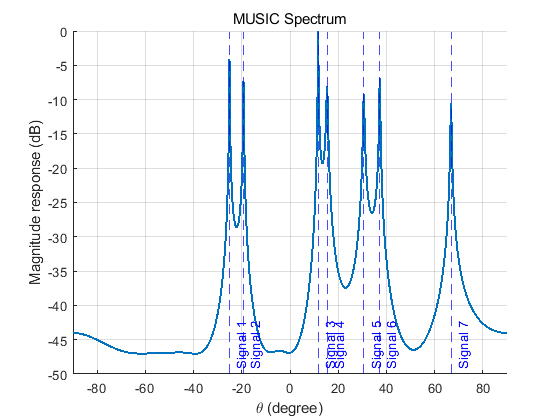

In [70]:
[U,V] = eig(R_xx);
ev = diag(V).';
[ev,I]=sort(ev); % find the eigenvalues correspond to signal subspace
ev=fliplr(ev);
U=fliplr(U(:,I));

Un = U(:,num_sources+1:end);
P_Music = zeros([length(theta_plot),1]);
for i = 1:length(theta_plot)
    a = steering_vector(theta_plot(i));
    P_Music(i) = 1/abs(a'*(Un*Un')*a);
end

P_Music = 10*log10(P_Music/(max(P_Music)));
[~, MUSIC_DOA] = findpeaks(P_Music(:).', theta_plot, ...
    'SortStr', 'descend', 'NPeaks', num_sources, ...
    'MinPeakDistance', 1);
MUSIC_DOA = sort(MUSIC_DOA(:).');
if numel(MUSIC_DOA) == num_sources
    rmse_music = sqrt(mean((MUSIC_DOA - sort(theta(:).')).^2));
else
    rmse_music = NaN;
    warning('MUSIC:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', numel(MUSIC_DOA));
end
fprintf('MUSIC estimated angles (degrees):\n');
disp(MUSIC_DOA);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('MUSIC RMSE = %.6f degrees\n', rmse_music);
figure;
hold on;
h_MUSIC= plot(theta_plot, P_Music, 'LineWidth', 1.5);

grid on;
xlim([-90 90]);
% ylim([-80 0]);

h_sig = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title('MUSIC Spectrum');


This also explained why Capon Spectrum can better separate noise and signal. For Capon spectrum $P_{\mathrm{Capon}}(\theta)=\frac{1}{\mathbf{a}^{H}(\theta)\mathbf{R}_{xx}^{-1}\mathbf{a}(\theta)}$ . Because 

$$
\mathbf{R}_{xx}
=\mathbf{U}_s(\boldsymbol{\Lambda}_s+\sigma^{2}\mathbf{I}_s)\mathbf{U}_s^{H}
+\sigma^{2}\mathbf{U}_n\mathbf{U}_n^{H}
$$

 . So 

$$
\begin{aligned}
\mathbf{R}_{xx}^{-1}
&=\mathbf{U}_s(\boldsymbol{\Lambda}_s+\sigma^{2}\mathbf{I}_s)^{-1}\mathbf{U}_s^{H}
+\frac{1}{\sigma^{2}}\mathbf{U}_n\mathbf{U}_n^{H}\\
&=\mathbf{U}_s\operatorname{diag}\!\left(
\frac{1}{\lambda_1+\sigma^{2}},\ldots,\frac{1}{\lambda_K+\sigma^{2}}
\right)\mathbf{U}_s^{H}
+\frac{1}{\sigma^{2}}\mathbf{U}_n\mathbf{U}_n^{H}
\end{aligned}
$$

 . Then




$$
\begin{aligned}
\mathbf{a}^{H}\mathbf{R}_{xx}^{-1}\mathbf{a}
&=\mathbf{a}^{H}\mathbf{U}_s
\operatorname{diag}\!\left(
\frac{1}{\lambda_1+\sigma^{2}},\ldots,\frac{1}{\lambda_K+\sigma^{2}}
\right)
\mathbf{U}_s^{H}\mathbf{a}\\
&\quad+\frac{1}{\sigma^{2}}\lVert\mathbf{U}_n^{H}\mathbf{a}\rVert_2^{2}
\end{aligned}
$$



When $\theta\in\{\theta_1,\theta_2,\ldots,\theta_K\}$ , the noise-subspace term vanishes, because each signal eigenvalue is much larger than $\sigma^{2}$ , so $\frac{1}{\lambda_i+\sigma^{2}}$ is small, which helps make the denominator of $P_{\mathrm{Capon}}(\theta)$ very small. Thus it will reach its peak at the DOA of impining signals.
 


### FFT-Accelerated MUSIC
The grid-searching step of MUSIC is time-consuming. For a ULA, the Vandermonde structure of the steering vector allows the spectrum on a uniform spatial-frequency grid to be evaluated by FFTs.

Let $Q=M-K$ be the dimension of the noise subspace and write

$$
\mathbf{U}_n=\begin{bmatrix}\mathbf{u}_1&\mathbf{u}_2&\cdots&\mathbf{u}_Q\end{bmatrix},
\qquad
\mathbf{u}_q=\begin{bmatrix}u_q[0]&u_q[1]&\cdots&u_q[M-1]\end{bmatrix}^{T}.
$$

Define the spatial frequency associated with $\theta_k$ as

$$
\omega_k=\frac{2\pi d}{\lambda}\sin(\theta_k),
\qquad
\mathbf{a}(\omega_k)=\begin{bmatrix}1&e^{-j\omega_k}&\cdots&e^{-j(M-1)\omega_k}\end{bmatrix}^{T}.
$$

The MUSIC denominator at $\theta_k$ is

$$
\begin{aligned}
D_k
&=\mathbf{a}^{H}(\omega_k)\mathbf{U}_n\mathbf{U}_n^{H}\mathbf{a}(\omega_k)\\
&=\left\lVert\mathbf{U}_n^{H}\mathbf{a}(\omega_k)\right\rVert_2^{2}\\
&=\left\lVert
\begin{bmatrix}
\displaystyle\sum_{m=0}^{M-1}u_1^{*}[m]e^{-jm\omega_k}\\
\displaystyle\sum_{m=0}^{M-1}u_2^{*}[m]e^{-jm\omega_k}\\
\vdots \\
\displaystyle\sum_{m=0}^{M-1}u_Q^{*}[m]e^{-jm\omega_k}
\end{bmatrix}
\right\rVert_2^{2}\\
&=\sum_{q=1}^{Q}\left|\sum_{m=0}^{M-1}u_q^{*}[m]e^{-jm\omega_k}\right|^2.
\end{aligned}
$$

For one spatial-frequency sample, define

$$
\mathbf{z}_k=\mathbf{U}_n^{H}\mathbf{a}(\omega_k)\in\mathbb{C}^{Q},
\qquad D_k=\lVert\mathbf{z}_k\rVert_2^2.
$$

To evaluate all grid points simultaneously, choose an FFT length $N_{\mathrm{FFT}}\ge M$ and define the ordinary (unshifted) DFT grid

$$
\bar{\omega}_k=\frac{2\pi k}{N_{\mathrm{FFT}}},
\qquad k=0,1,\ldots,N_{\mathrm{FFT}}-1.
$$

Collecting all frequency samples gives

$$
\begin{aligned}
\mathbf{Z}
&=\begin{bmatrix}\mathbf{z}(\bar{\omega}_0)&\mathbf{z}(\bar{\omega}_1)&\cdots&\mathbf{z}(\bar{\omega}_{N_{\mathrm{FFT}}-1})\end{bmatrix}\in\mathbb{C}^{Q\times N_{\mathrm{FFT}}},\\
Z_{q,k}
&=\sum_{m=0}^{M-1}u_q^{*}[m]e^{-j2\pi km/N_{\mathrm{FFT}}}.
\end{aligned}
$$

Thus we can first zero-pad each conjugated noise eigenvector to length $N_{\mathrm{FFT}}$, then apply the $N_{\mathrm{FFT}}$-point FFT to each zero-padded row vector of $\mathbf{U}_n^H$ to obtain $\mathbf{Z}$, at last, by summing the squared magnitude of each column of $\mathbf{Z}$, we can obtain the MUSIC denominator for all grid points simultaneously. 
Finally, we shall convert the spatial frequency $\omega_k$ to the angle $\theta_k$ using
$$
\theta_k = \arcsin\!\left(\frac{\lambda\omega_k}{2\pi d}\right).
$$
<!-- Equivalently, zero-pad each conjugated noise eigenvector to length $N_{\mathrm{FFT}}$ by defining

$$
x_q[m]=
\begin{cases}
u_q^{*}[m],&0\le m<M,\\
0,&M\le m<N_{\mathrm{FFT}}.
\end{cases}
$$

Then

$$
Z_{q,k}
=\sum_{m=0}^{N_{\mathrm{FFT}}-1}x_q[m]e^{-j2\pi km/N_{\mathrm{FFT}}}
=\operatorname{DFT}_{N_{\mathrm{FFT}}}\{x_q[m]\}[k].
$$

Therefore, the $q$-th row of $\mathbf{Z}$ is the $N_{\mathrm{FFT}}$-point DFT of the zero-padded sequence $u_q^{*}[m]$. Because the DFT is $2\pi$-periodic, the unshifted grid must be wrapped to the centered spatial-frequency interval before converting it to angle. For even $N_{\mathrm{FFT}}$, define

$$
\omega_k=
\begin{cases}
\dfrac{2\pi k}{N_{\mathrm{FFT}}},&0\le k<\dfrac{N_{\mathrm{FFT}}}{2},\\[6pt]
\dfrac{2\pi(k-N_{\mathrm{FFT}})}{N_{\mathrm{FFT}}},&\dfrac{N_{\mathrm{FFT}}}{2}\le k<N_{\mathrm{FFT}}.
\end{cases}
$$

After retaining the physically valid bins $|\omega_k|\le 2\pi d/\lambda$, the FFT-accelerated MUSIC spectrum is obtained from

$$
D_k=\sum_{q=1}^{Q}|Z_{q,k}|^2,
\qquad
P_{\mathrm{MUSIC}}(\theta_k)=\frac{1}{D_k},
\qquad
\theta_k=\arcsin\!\left(\frac{\lambda\omega_k}{2\pi d}\right).
$$ -->


FFT-accelerated MUSIC estimated angles (degrees):
  -25.0765  -19.2735   11.6626   15.3751   30.6157   37.2274   66.7724

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

FFT-accelerated MUSIC RMSE = 0.053477 degrees


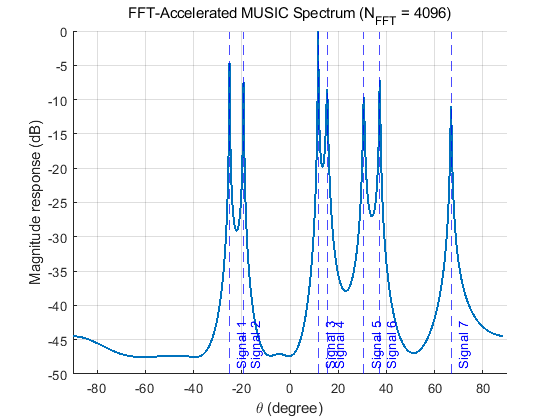

In [71]:
% Evaluate the MUSIC denominator on a zero-padded FFT grid.
N_fft_music = 4096;
Z_fft_music = fftshift(fft(conj(Un), N_fft_music, 1), 1);
D_fft_music = sum(abs(Z_fft_music).^2, 2);
P_Music_FFT = 1 ./ max(D_fft_music, eps);

% Convert the centered spatial-frequency grid to physical angles.
omega_fft_music = (-N_fft_music/2:N_fft_music/2-1).' ...
    * (2*pi/N_fft_music);
valid_fft_music = abs(omega_fft_music) <= 2*pi*d;
omega_fft_music = omega_fft_music(valid_fft_music);
P_Music_FFT = P_Music_FFT(valid_fft_music);
sin_theta_fft_music = omega_fft_music/(2*pi*d);
sin_theta_fft_music = max(-1, min(1, sin_theta_fft_music));
theta_fft_music = asind(sin_theta_fft_music);

% Normalize the FFT-accelerated MUSIC spectrum and estimate its peaks.
P_Music_FFT = 10*log10(P_Music_FFT/max(P_Music_FFT));
[~, FFT_MUSIC_DOA] = findpeaks(P_Music_FFT(:).', ...
    theta_fft_music(:).', 'SortStr', 'descend', ...
    'NPeaks', num_sources, 'MinPeakDistance', 1);
FFT_MUSIC_DOA = sort(FFT_MUSIC_DOA(:).');

if numel(FFT_MUSIC_DOA) == num_sources
    rmse_fft_music = sqrt(mean((FFT_MUSIC_DOA ...
        - sort(theta(:).')).^2));
else
    rmse_fft_music = NaN;
    warning('FFT_MUSIC:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', ...
        numel(FFT_MUSIC_DOA));
end

fprintf('FFT-accelerated MUSIC estimated angles (degrees):\n');
disp(FFT_MUSIC_DOA);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('FFT-accelerated MUSIC RMSE = %.6f degrees\n', ...
    rmse_fft_music);

figure;
hold on;
h_FFT_MUSIC = plot(theta_fft_music, P_Music_FFT, ...
    'LineWidth', 1.5);
grid on;
xlim([-90 90]);

h_sig_fft_music = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig_fft_music(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title(sprintf('FFT-Accelerated MUSIC Spectrum (N_{FFT} = %d)', ...
    N_fft_music));

Also, the matrix contains noise eigenvector is usually larger than which is consist of signal eigenvectors, thus we can also use the signal subspace to accelerate the computation. 
Because $\mathbf{U}_s$ and $\mathbf{U}_n$ are orthogonal to each other, we have 
$$ \mathbf{U}_s^{H}\mathbf{U}_n=\mathbf{0} \implies \mathbf{U}_n\mathbf{U}_n^{H}=\mathbf{I}-\mathbf{U}_s\mathbf{U}_s^{H} $$
Thus 
\begin{aligned}
D_k
&=\mathbf{a}^{H}(\omega_k)\mathbf{U}_n\mathbf{U}_n^{H}\mathbf{a}(\omega_k)\\ 
&=\mathbf{a}^{H}(\omega_k)(\mathbf{I}-\mathbf{U}_s\mathbf{U}_s^{H})\mathbf{a}(\omega_k)\\
&=\mathbf{a}^{H}(\omega_k)\mathbf{a}(\omega_k)-\mathbf{a}^{H}(\omega_k)\mathbf{U}_s\mathbf{U}_s^{H}\mathbf{a}(\omega_k)\\
&=M-\mathbf{a}^{H}(\omega_k)\mathbf{U}_s\mathbf{U}_s^{H}\mathbf{a}(\omega_k)
\end{aligned}

The process of computing $\mathbf{a}^{H}(\omega_k)\mathbf{U}_s\mathbf{U}_s^{H}\mathbf{a}(\omega_k)$ is similar to the process of computing $\mathbf{a}^{H}(\omega_k)\mathbf{U}_n\mathbf{U}_n^{H}\mathbf{a}(\omega_k)$.

FFT-accelerated MUSIC estimated angles (degrees):
  -25.2310  -19.3328   11.5769   15.3751   30.4209   37.2977   66.7724

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

FFT-accelerated MUSIC RMSE = 0.114274 degrees


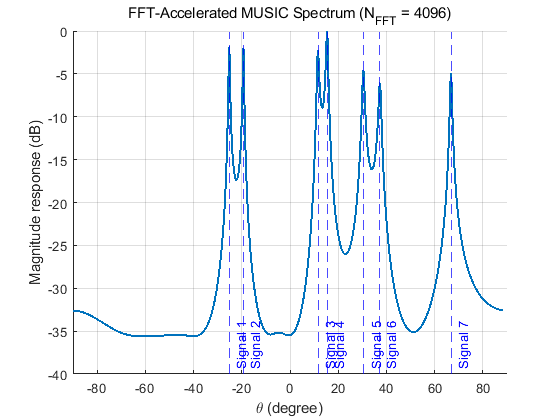

In [72]:
% Evaluate the MUSIC denominator on a zero-padded FFT grid.
N_fft_music = 4096;
Z_fft_music = fftshift(fft(conj(Us), N_fft_music, 1), 1);
D_fft_music = sum(abs(Z_fft_music).^2, 2);
P_Music_FFT = 1 ./ max(M-D_fft_music, eps);

% Convert the centered spatial-frequency grid to physical angles.
omega_fft_music = (-N_fft_music/2:N_fft_music/2-1).' ...
    * (2*pi/N_fft_music);
valid_fft_music = abs(omega_fft_music) <= 2*pi*d;
omega_fft_music = omega_fft_music(valid_fft_music);
P_Music_FFT = P_Music_FFT(valid_fft_music);
sin_theta_fft_music = omega_fft_music/(2*pi*d);
sin_theta_fft_music = max(-1, min(1, sin_theta_fft_music));
theta_fft_music = asind(sin_theta_fft_music);

% Normalize the FFT-accelerated MUSIC spectrum and estimate its peaks.
P_Music_FFT = 10*log10(P_Music_FFT/max(P_Music_FFT));
[~, FFT_MUSIC_DOA] = findpeaks(P_Music_FFT(:).', ...
    theta_fft_music(:).', 'SortStr', 'descend', ...
    'NPeaks', num_sources, 'MinPeakDistance', 1);
FFT_MUSIC_DOA = sort(FFT_MUSIC_DOA(:).');

if numel(FFT_MUSIC_DOA) == num_sources
    rmse_fft_music = sqrt(mean((FFT_MUSIC_DOA ...
        - sort(theta(:).')).^2));
else
    rmse_fft_music = NaN;
    warning('FFT_MUSIC:InsufficientPeaks', ...
        'Only %d peaks were detected; RMSE is undefined.', ...
        numel(FFT_MUSIC_DOA));
end

fprintf('FFT-accelerated MUSIC estimated angles (degrees):\n');
disp(FFT_MUSIC_DOA);
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('FFT-accelerated MUSIC RMSE = %.6f degrees\n', ...
    rmse_fft_music);

figure;
hold on;
h_FFT_MUSIC = plot(theta_fft_music, P_Music_FFT, ...
    'LineWidth', 1.5);
grid on;
xlim([-90 90]);

h_sig_fft_music = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig_fft_music(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
ylabel('Magnitude response (dB)');
title(sprintf('FFT-Accelerated MUSIC Spectrum (N_{FFT} = %d)', ...
    N_fft_music));

This technique can be used to accelerate Capon spectrum as well.

 
### ESPRIT

While MUSIC uses the orthogonality between the array steering vectors and the noise subspace,  *Estimation of Signal Parameter via Rotational Invariance Techniques(ESPRIT)* utilizes the rotational invariance of array for estimating doa.


Dividing the array into 2 subarrays $\mathbf{A}_1,\mathbf{A}_2$ . The first array contains $1\rightarrow M-1$ elements and the second array contains $2\rightarrow M$ elements, i.e. $\mathbf{A}_1=\mathbf{J}_1\mathbf{A},\qquad\mathbf{A}_2=\mathbf{J}_2\mathbf{A}$ , where $\mathbf{J}_1=\begin{bmatrix}\mathbf{I}_{M-1}&\mathbf{0}\end{bmatrix},\qquad\mathbf{J}_2=\begin{bmatrix}\mathbf{0}&\mathbf{I}_{M-1}\end{bmatrix}$ . Thus the signals received by different subarrays can be written as


 $\begin{cases}
\mathbf{x}_1(t)=\mathbf{A}_1\mathbf{s}(t)+\mathbf{n}_1(t),\\
\mathbf{x}_2(t)=\mathbf{A}_2\mathbf{s}(t)+\mathbf{n}_2(t)
\end{cases}$ .


The relationship between $\mathbf{A}_1$ and $\mathbf{A}_2$ is demonstrated as follows:




$$
\begin{aligned}
\mathbf{A}_1
&=\mathbf{J}_1\mathbf{A}\\
&=\begin{bmatrix}
1&1&\cdots&1\\
e^{-j\frac{2\pi d}{\lambda}\sin(\theta_1)}
&e^{-j\frac{2\pi d}{\lambda}\sin(\theta_2)}
&\cdots
&e^{-j\frac{2\pi d}{\lambda}\sin(\theta_K)}\\
\vdots&\vdots&\ddots&\vdots\\
e^{-j\frac{2\pi(M-2)d}{\lambda}\sin(\theta_1)}
&e^{-j\frac{2\pi(M-2)d}{\lambda}\sin(\theta_2)}
&\cdots
&e^{-j\frac{2\pi(M-2)d}{\lambda}\sin(\theta_K)}
\end{bmatrix}
\end{aligned}
$$

while,

$$
\begin{aligned}
\mathbf{A}_2
&=\mathbf{J}_2\mathbf{A}\\
&=\begin{bmatrix}
e^{-j\frac{2\pi d}{\lambda}\sin(\theta_1)}
&e^{-j\frac{2\pi d}{\lambda}\sin(\theta_2)}
&\cdots
&e^{-j\frac{2\pi d}{\lambda}\sin(\theta_K)}\\
\vdots&\vdots&\ddots&\vdots\\
e^{-j\frac{2\pi(M-1)d}{\lambda}\sin(\theta_1)}
&e^{-j\frac{2\pi(M-1)d}{\lambda}\sin(\theta_2)}
&\cdots
&e^{-j\frac{2\pi(M-1)d}{\lambda}\sin(\theta_K)}

\end{bmatrix}
\end{aligned}
$$

Thus, we have $\mathbf{A}_2=\mathbf{A}_1\boldsymbol{\Phi}$ , where $\boldsymbol{\Phi}=\operatorname{diag}\!\left(e^{-j\frac{2\pi d}{\lambda}\sin(\theta_1)},e^{-j\frac{2\pi d}{\lambda}\sin(\theta_2)},\ldots,e^{-j\frac{2\pi d}{\lambda}\sin(\theta_K)}\right)$ . 
It means the 2 subarrays share the same signal subspace and structure, the difference is only a phase shift related to DOA, which means if we can estimate the diagonal matrix $\boldsymbol{\Phi}$, we can estimate the DOA.
This is the rotational invariance property of array manifold matrix $\mathbf{A}$.

Based on the rotational invariance property, we can estimate the DOA by estimating the diagonal matrix $\boldsymbol{\Phi}$.
Define the signal received by 2 subarrays as $\mathbf{X}_1=\mathbf{A}_1\mathbf{S}+\mathbf{N}_1$ and $\mathbf{X}_2=\mathbf{A}_2\mathbf{S}+\mathbf{N}_2 = \mathbf{A}_1\boldsymbol{\Phi}\mathbf{S}+\mathbf{N}_2$. 

According to the analysis in MUSIC section, $\operatorname{span}(\mathbf{U}_s)=\operatorname{span}(\mathbf{A})$. Thus there is a nonsigular matrix $\mathbf{T}$ such that $\mathbf{U}_s=\mathbf{A}\mathbf{T}$ . 

Because 
$$
\begin{aligned}
\mathbf{U}_{s,1} &\triangleq \mathbf{J}_1\mathbf{U}_s \\
\mathbf{U}_{s,2} &\triangleq \mathbf{J}_2\mathbf{U}_s
\end{aligned}
$$

Then we have $\mathbf{U}_{s,1}=\mathbf{A}_1\mathbf{T}$ and $\mathbf{U}_{s,2}=\mathbf{A}_2\mathbf{T}=\mathbf{A}_1\boldsymbol{\Phi}\mathbf{T}$.  

Therefore, $\mathbf{U}_{s,2}=\mathbf{U}_{s,1}\mathbf{T}^{-1}\boldsymbol{\Phi}\mathbf{T}=\mathbf{U}_{s,1}\boldsymbol{\Psi}$ . $\boldsymbol{\Psi}$ is a similar matrix of $\boldsymbol{\Phi}$, which means they have the same eigenvalues. Different estimation methods leads to different types of ESPRIT.

In [73]:
% Recompute the signal subspace so ESPRIT can run independently of the MUSIC section.
R_esprit = (R_xx + R_xx')/2; % enforce Hermitian symmetry
[U_esprit, D_esprit] = eig(R_esprit);
[~, order] = sort(real(diag(D_esprit)), 'descend');
Us = U_esprit(:, order(1:num_sources)); % signal subspace
E1 = Us(1:end-1,:);
E2 = Us(2:end,:);

#### LS-ESPRIT

We can apply the least-squares method to estimate $\boldsymbol{\Psi}$:

$$
\underset{\boldsymbol{\Psi}}{\min}
\;\left\lVert\mathbf{U}_{s,2}-\mathbf{U}_{s,1}\boldsymbol{\Psi}\right\rVert_F^{2}.
$$

The solution is $\hat{\boldsymbol{\Psi}}=(\mathbf{U}_{s,1}^{H}\mathbf{U}_{s,1})^{-1}\mathbf{U}_{s,1}^{H}\mathbf{U}_{s,2}$ . Or by the definition of the pseudoinverse, $\hat{\boldsymbol{\Psi}}=\mathbf{U}_{s,1}^{\dagger}\mathbf{U}_{s,2}$ .
Then we can estimate the DOA by calculating the eigenvalues of $\hat{\boldsymbol{\Psi}}$.


LS-ESPRIT estimated angles (degrees):
  -25.1166  -19.2592   11.6872   15.3595   30.6849   37.1616   66.8399

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

LS-ESPRIT RMSE = 0.067745 degrees


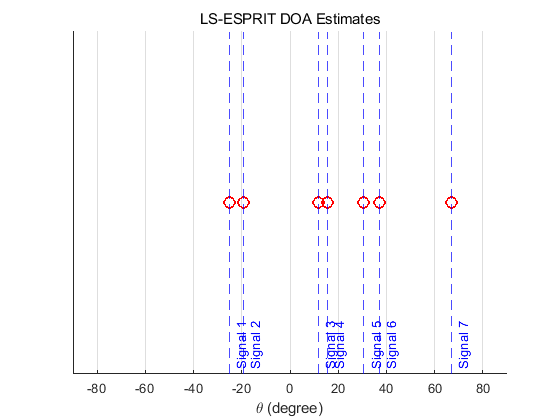

In [74]:
Psi_ls = E1 \ E2; % LS estimate: minimize ||E2 - E1*Psi||_F
phase_shift_ls = eig(Psi_ls);
sin_theta_ls = -angle(phase_shift_ls)/(2*pi*d);
sin_theta_ls = max(min(real(sin_theta_ls), 1), -1); % protect asind from roundoff
angles_ls = sort(asind(sin_theta_ls));
disp('LS-ESPRIT estimated angles (degrees):');
disp(angles_ls.');
rmse_ls_esprit = sqrt(mean((angles_ls(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('LS-ESPRIT RMSE = %.6f degrees\n', rmse_ls_esprit);
figure;
hold on;

h_ESPRIT = plot(angles_ls, zeros(size(angles_ls)), 'ro', 'MarkerSize', 8, 'LineWidth', 1.5);

grid on;
xlim([-90 90]);
ylim([-1 1]);

h_sig = gobjects(1, numel(theta));
for ii = 1:numel(theta)
    h_sig(ii) = xline(theta(ii), 'b--', ...
        sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title('LS-ESPRIT DOA Estimates');

#### TLS-ESPRIT

Because in practice, the signal subspace $\mathbf{U}_s$ is estimated from the noisy covariance matrix $\hat{\mathbf{R}}_{xx}$, both $\hat{\mathbf{U}}_{s,1}$ and $\hat{\mathbf{U}}_{s,2}$ are contaminated by noise. Therefore, a total least squares (TLS) approach can be used to estimate $\boldsymbol{\Psi}$. The TLS solution minimizes the Frobenius norm of the correction in both $\hat{\mathbf{U}}_{s,1}$ and $\hat{\mathbf{U}}_{s,2}$ simultaneously. And $\mathbf{U}_{s,1} = \hat{\mathbf{U}}_{s,1}+\Delta\mathbf{U}_{s,1} \, \mathbf{U}_{s,2} = \hat{\mathbf{U}}_{s,2}+\Delta\mathbf{U}_{s,2}$. According to rotation invariant property, we have $\mathbf{U}_{s,2} = \mathbf{U}_{s,1}\boldsymbol{\Psi}$, which leads to the constraint $\hat{\mathbf{U}}_{s,2} + \Delta\mathbf{U}_{s,2} = (\hat{\mathbf{U}}_{s,1} + \Delta\mathbf{U}_{s,1}) \boldsymbol{\Psi}$.

The TLS problem can be formulated as:

$$ 
\begin{cases}
& \underset{\Delta\mathbf{U}_{s,1},\,\Delta\mathbf{U}_{s,2},\,\boldsymbol{\Psi}}{\min} \; \left\lVert \Delta\mathbf{U}_{s,1} \right\rVert_F^2 + \left\lVert \Delta\mathbf{U}_{s,2} \right\rVert_F^2 \\
& \text{s.t. } \hat{\mathbf{U}}_{s,2} + \Delta\mathbf{U}_{s,2} = (\hat{\mathbf{U}}_{s,1} + \Delta\mathbf{U}_{s,1}) \boldsymbol{\Psi}
\end{cases}
$$

Using the constraint, it can be rewritten as 
$ (\begin{bmatrix} \hat{\mathbf{U}}_{s,1} & \hat{\mathbf{U}}_{s,2} \end{bmatrix} +\begin{bmatrix} \Delta\mathbf{U}_{s,1} & \Delta\mathbf{U}_{s,2} \end{bmatrix})  \begin{bmatrix} \boldsymbol{\Psi} \\ -\mathbf{I}_K \end{bmatrix} = \mathbf{0} $

We define the observed signal-subspace augmented matrix $\hat{\mathbf{Z}} = \begin{bmatrix} \hat{\mathbf{U}}_{s,1} & \hat{\mathbf{U}}_{s,2} \end{bmatrix}$ and the perturbation matrix $\Delta\mathbf{Z} = \begin{bmatrix} \Delta\mathbf{U}_{s,1} & \Delta\mathbf{U}_{s,2} \end{bmatrix}$. The augmented matrix after correction is 
$\mathbf{Z}=\hat{\mathbf{Z}} + \Delta\mathbf{Z}$. So the TLS problem can be reformulated as 
    
$$
\begin{cases}
& \underset{\mathbf{Z}}{\min} \; \left\lVert \hat{\mathbf{Z}}- \mathbf{Z} \right\rVert_F^2 \\
& \text{s.t. } \mathbf{Z} \begin{bmatrix} \boldsymbol{\Psi} \\ -\mathbf{I}_K \end{bmatrix} = \mathbf{0}
\end{cases}
$$

The equality constraint implies $ \operatorname{span}(\begin{bmatrix} \boldsymbol{\Psi} \\ -\mathbf{I}_K \end{bmatrix}) \subseteq \operatorname{null}(\mathbf{Z}) $. Since the matrix inside the span has column rank $K$, the rank-nullity theorem gives $ \operatorname{rank}(\mathbf{Z}) \le K $. Replacing the equality constraint by this necessary rank condition gives the relaxed problem
$$ 
\begin{cases}
& \underset{\mathbf{Z}}{\min} \; \left\lVert \hat{\mathbf{Z}}- \mathbf{Z} \right\rVert_F^2 \\
& \text{s.t. } \operatorname{rank}(\mathbf{Z}) \le K
\end{cases}
$$

This is a low-rank approximation problem. Let $p_{\mathrm{LR}}^{\star}$ and $p_{\mathrm{TLS}}^{\star}$ denote the optimal values of the relaxed and original TLS problems, respectively. Because the relaxed feasible set is larger, $p_{\mathrm{LR}}^{\star}\le p_{\mathrm{TLS}}^{\star}$. As proved in the appendix, this lower bound is attained when the first block of a selected relaxed optimizer has column rank $K$, equivalently when $\mathbf{V}_{22}$ is nonsingular.

The low-rank approximation problem can be solved by the Eckart--Young theorem. Applying SVD to $\hat{\mathbf{Z}}$, we have $\hat{\mathbf{Z}} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^H$. A relaxed optimizer is $\mathbf{Z}_{\mathrm{LR}}^{\star} = \mathbf{U}_K\boldsymbol{\Sigma}_K\mathbf{V}_K^H$, where $\mathbf{U}_K$, $\boldsymbol{\Sigma}_K$, and $\mathbf{V}_K$ correspond to the $K$ largest singular values of $\hat{\mathbf{Z}}$. The relaxed optimal value is $p_{\mathrm{LR}}^{\star} = \sum_{i=K+1}^{2K} \sigma_i^2$, where zero singular values are appended when necessary.

By the definition of SVD, we have $\mathbf{V}^H\mathbf{V} = \mathbf{I}$, which means the columns of $\mathbf{V}$ are orthonormal. The null space of $\mathbf{Z}_{\mathrm{LR}}^{\star}$ is spanned by the last $K$ columns of $\mathbf{V}$, denoted as $\mathbf{V}_n$. Thus, we can write $\mathbf{V}$ as the partitioned matrix
$\mathbf{V} = [\mathbf{V}_K \; \mathbf{V}_n] = 
\begin{bmatrix} 
\mathbf{V}_{11} & \mathbf{V}_{12} \\
\mathbf{V}_{21} & \mathbf{V}_{22}
\end{bmatrix}
$, 
where $\mathbf{V}_K$ corresponds to the $K$ largest singular values and $\mathbf{V}_n$ corresponds to the null space. Then we have

$$
\begin{aligned}

\mathbf{Z}_{\mathrm{LR}}^{\star}\mathbf{V}_n &= \mathbf{0} \\

\begin{bmatrix} \mathbf{Z}_{1}^{\star} & \mathbf{Z}_{2}^{\star} \end{bmatrix} \begin{bmatrix} \mathbf{V}_{12} \\ \mathbf{V}_{22} \end{bmatrix} &= \mathbf{0} \\

\mathbf{Z}_{1}^{\star}\mathbf{V}_{12}+\mathbf{Z}_{2}^{\star}\mathbf{V}_{22} &= \mathbf{0} \\ 

\mathbf{Z}_{1}^{\star}\mathbf{V}_{12} &= -\mathbf{Z}_{2}^{\star}\mathbf{V}_{22} \\

\mathbf{Z}_{2}^{\star} &= \mathbf{Z}_{1}^{\star}(-\mathbf{V}_{12}\mathbf{V}_{22}^{-1}) \\

\end{aligned}
$$

Assuming that $\mathbf{V}_{22}$ is nonsingular, we can estimate $\boldsymbol{\Psi}$ as $\hat{\boldsymbol{\Psi}} = -\mathbf{V}_{12}\mathbf{V}_{22}^{-1}$. Finally, the DOA can be estimated from the eigenvalues of $\hat{\boldsymbol{\Psi}}$.

TLS-ESPRIT estimated angles (degrees):
  -25.1169  -19.2592   11.6887   15.3579   30.6894   37.1575   66.8386

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

TLS-ESPRIT RMSE = 0.069232 degrees


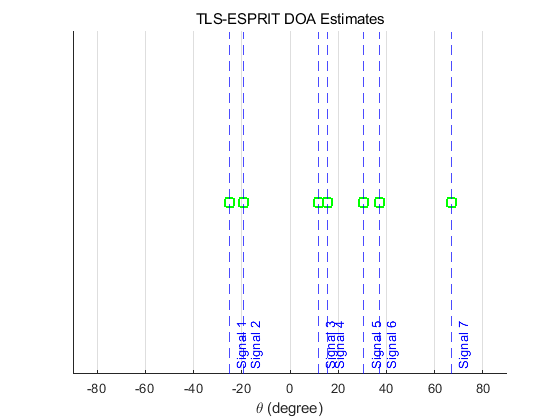

In [75]:
Z_tls = [E1, E2];
[~, sigma, V_tls] = svd(Z_tls);
K = num_sources;
V12 = V_tls(1:K, K+1:2*K);
V22 = V_tls(K+1:2*K, K+1:2*K);
Psi_tls = -V12 / V22; % TLS solution from the estimated right-null subspace
phase_shift_tls = eig(Psi_tls);
sin_theta_tls = -angle(phase_shift_tls)/(2*pi*d);
sin_theta_tls = max(min(real(sin_theta_tls), 1), -1);
angles_tls = sort(asind(sin_theta_tls));
disp('TLS-ESPRIT estimated angles (degrees):');
disp(angles_tls.');
rmse_tls_esprit = sqrt(mean((angles_tls(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('TLS-ESPRIT RMSE = %.6f degrees\n', rmse_tls_esprit);

figure;
hold on;
plot(angles_tls, zeros(size(angles_tls)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title('TLS-ESPRIT DOA Estimates');


## Part III: Parametric Methods

### Maximum Likelihood Methods

The parametric methods directly utilize the statistical properties of the received signal to estimate the DOA. One of the most widely used parametric methods is Maximum Likelihood Estimation (MLE). And there are 2 types of MLE, deterministic MLE and stochastic MLE. The received signal model is often modeled as 

$$
\begin{equation}
\mathbf{x}(n) = \mathbf{A}\mathbf{s}(n)+\mathbf{n}(n),\quad n=1,2,\ldots,N
\end{equation}
$$
With the noise $\mathbf{n}(n)$ being modeled as a zero-mean complex Gaussian random vector with covariance matrix $\sigma^2\mathbf{I}$. The snapshots $\mathbf{s}(n)$ can be modeled as either deterministic or stochastic, leading to different formulations of the likelihood function.
#### Deterministic Maximum Likelihood(DML)

In DML, the snapshots $\mathbf{s}(n)$ is viewed as the relaxation of a fixed stochastic process, which means the snapshots are deterministic but unknown. According to the assumption above, the received signal $\mathbf{x}(n) \sim \mathcal{CN}(\mathbf{A}(\boldsymbol{\theta})\mathbf{s}(n), \sigma^2\mathbf{I})$. Because the snapshots are identically and independently distributed(i.i.d.), the likelihood function can be written as

$$
\mathcal{L}(\boldsymbol{\theta},\mathbf{s},\sigma^2) = \prod_{n=1}^N p(\mathbf{x}(n);\boldsymbol{\theta}) = \prod_{n=1}^N \frac{1}{(\pi\sigma^2)^M} \exp\left(-\frac{1}{\sigma^2}\|\mathbf{x}(n) - \mathbf{A}(\boldsymbol{\theta})\mathbf{s}(n)\|_2^2\right)
$$

The log-likelihood function is then given by 
$$
\ln \mathcal{L}(\boldsymbol{\theta},\mathbf{s},\sigma^2) = -NM\ln(\pi\sigma^2) - \frac{1}{\sigma^2}\sum_{n=1}^N \|\mathbf{x}(n) - \mathbf{A}(\boldsymbol{\theta})\mathbf{s}(n)\|_2^2
$$

MLE aims to maximize the log-likelihood function with respect to $\boldsymbol{\theta}, \mathbf{s},$ and $\sigma^2$. However, the high dimension of parameter space makes direct maximization computationally expensive. To simplify, we can first estimate $\mathbf{s}$ and $\sigma^2$ for a given $\boldsymbol{\theta}$, and then maximize the resulting function with respect to $\boldsymbol{\theta}$.

For a fixed $\boldsymbol{\theta}$, the least-squares estimate of $\mathbf{s}$ is given by
$$
\hat{\mathbf{s}}(n) = (\mathbf{A}^H(\boldsymbol{\theta})\mathbf{A}(\boldsymbol{\theta}))^{-1}\mathbf{A}^H(\boldsymbol{\theta})\mathbf{x}(n) = \mathbf{A}^{\dagger}(\boldsymbol{\theta})\mathbf{x}(n)
$$ 

Where $\mathbf{A}^{\dagger}(\boldsymbol{\theta})$ is the Moore-Penrose pseudoinverse of $\mathbf{A}(\boldsymbol{\theta})$. Substituting this estimate back into the log-likelihood function, we have
$$
\begin{aligned}
\ln \mathcal{L}(\boldsymbol{\theta},\sigma^2) &= -NM\ln(\pi\sigma^2) - \frac{1}{\sigma^2}\sum_{n=1}^N \|\mathbf{x}(n) - \mathbf{A}(\boldsymbol{\theta})\mathbf{A}^{\dagger}(\boldsymbol{\theta})\mathbf{x}(n)\|_2^2 \\

 &= -NM\ln(\pi\sigma^2) - \frac{1}{\sigma^2}\sum_{n=1}^N \|\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\mathbf{x}(n)\|_2^2
\end{aligned}
$$

Where $\mathbf{P} = \mathbf{A}(\boldsymbol{\theta})\mathbf{A}^{\dagger}(\boldsymbol{\theta})$ is the projection matrix onto the column space of $\mathbf{A}(\boldsymbol{\theta})$, and $\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta}) = \mathbf{I} - \mathbf{A}(\boldsymbol{\theta})\mathbf{A}^{\dagger}(\boldsymbol{\theta})$ is the orthogonal projection matrix onto the null space of $\mathbf{A}(\boldsymbol{\theta})$. The last term can be rewritten as
$$
\sum_{n=1}^N \|\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\mathbf{x}(n)\|_2^2 = N\operatorname{tr}(\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx})
$$

Then maximizing the log-likelihood function with respect to $\sigma^2$ gives the estimate
$$
\hat{\sigma}^2 = \frac{1}{M}\operatorname{tr}(\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx})
$$

Substituting this back into the log-likelihood function, we obtain the concentrated log-likelihood function
$$
\ln \mathcal{L}(\boldsymbol{\theta}) = -NM\ln\left(\frac{\pi}{M}\operatorname{tr}(\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx})\right) - NM
$$

Thus the DML estimate of $\boldsymbol{\theta}$ is obtained by minimizing the trace of the projection of the sample covariance matrix onto the orthogonal complement of the array manifold:
$$
\hat{\boldsymbol{\theta}}_{\mathrm{DML}} = \arg\min_{\boldsymbol{\theta}} \operatorname{tr}(\mathbf{P}_{\mathbf{A}}^{\perp}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx})
$$
However, the DML method requires a multidimensional search over the parameter space, which can be computationally intensive, especially for large arrays or multiple sources. So for implemention, people often use some non-linear and non-convex optimization algorithms. Here, I shall introduce some of the widely used ones.


##### 1.Alternating projection algorithm(APA)
Equivalently, we can rewrite the DML problem as
$$
\hat{\boldsymbol{\theta}}_{\mathrm{DML}} = \arg\max_{\boldsymbol{\theta}} \operatorname{tr}(\mathbf{P}_{\mathbf{A}}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx})
$$
This equation indicates that minimizing the projection of the sample covariance matrix onto the orthogonal complement of the array manifold is equivalent to maximizing the projection onto the array manifold itself. 

The idea of APA is strightforward. It is an interative technique in which, at each step, we hold all but one of the parameters fixed and optimize over the remaining parameter. This process is repeated for each parameter in turn, and the entire cycle is repeated until convergence. Thus, the value of $\hat \theta_i$ at the (k+1)-th iteration can be updated by fixing the other parameters $\hat \theta_j$ for $j\neq i$ and solving the one-dimensional optimization problem(Gauss-Seidel Update):
$$
\hat \theta_i^{k+1} = \arg\max_{\theta_i} \operatorname{tr}(\mathbf{P}_{\mathbf{A}}(\hat{\theta}_1^{k+1}, \ldots, \hat{\theta}_{i-1}^{k+1}, \vartheta_i, \hat{\theta}_{i+1}^k, \ldots, \hat{\theta}_K^k)\hat{\mathbf{R}}_{xx})
$$

Define the projection matrix $\mathbf{P}_{\mathbf{A}}(\hat{\theta}_1^k, \ldots, \hat{\theta}_{i-1}^k, \vartheta_i, \hat{\theta}_{i+1}^k, \ldots, \hat{\theta}_K^k)$ as $\mathbf{P}_{\vartheta_i,\mathbf{A}_{-i}}$ for simplicity. Then the optimization problem reduces to a one-dimensional search over $\vartheta_i$. Due to the property of projection matrix, we spilit the projection matrix into 2 parts
$$
\mathbf{P}_{\vartheta_i,\mathbf{A}_{-i}} = \mathbf{P}_{\vartheta_i(\mathbf{A}_{-i})}+\mathbf{P}_{\mathbf{A}_{-i}}
$$
Where $\vartheta(\mathbf{A}_{-i}) = \mathbf{q}(\vartheta_i) = \mathbf{P}_{\mathbf{A}_{-i}}^\perp \mathbf{a}(\vartheta_i)= (\mathbf{I}-\mathbf{A}_{-i}\mathbf{A}_{-i}^\dagger)\mathbf{a}(\vartheta_i) $, $\mathbf{A}_{-i}$ is the array manifold matrix excluding the direction $\vartheta$. This property means that projection matrix can be separated into 2 orthogonal matrices. Thus $\mathbf{P}_{\vartheta_i(\mathbf{A}_{-i})} = \mathbf{q}(\mathbf{q}^H\mathbf{q})^{-1}\mathbf{q}^H = \frac{\mathbf{q}\mathbf{q}^H}{\lVert \mathbf{q}\rVert_2^2}$. Lets denote the normalized vector $\frac{\mathbf{\mathbf{q}}}{\lvert\mathbf{q}\rvert_2}$ as $\mathbf{b}$. Then the optimization problem for
$$
\theta_i^{k+1} =\arg\max_{\theta_i} \operatorname{tr}(\mathbf{b}\mathbf{b}^H \hat{\mathbf{R}}_{xx})
$$
According to cyclic property of trace, the ultimate optimization is
$$
\theta_i^{k+1} =\arg\max_{\vartheta} \mathbf{b}^H(\vartheta)\hat{\mathbf{R}}_{xx}\mathbf{b}(\vartheta)
$$
, or

$$
\theta_i^{k+1} =\arg\max_{\vartheta} \frac{\mathbf{a}^H(\vartheta)\mathbf{P}_{\mathbf{A}_{-i}}^\perp \hat{\mathbf{R}}_{xx}\mathbf{P}_{\mathbf{A}_{-i}}^\perp\mathbf{a}(\vartheta)}{\mathbf{a}^H(\vartheta)\mathbf{P}_{\mathbf{A}_{-i}}^\perp\mathbf{a}(\vartheta)}
$$

The initial value can be given by DBF. Here I introduce the original version of estimating initial values.

$\hat{\theta}_{1}^{0}$ is obtained by finding the maximum of DBF spectrum. Then we can fix the $\hat{\theta}_{1}^{0}$ to search for the second one
$$
\hat{\theta}_{2}^{0} = \arg\max_{\theta_2} \operatorname{tr}\left[\mathbf{P}_{\vartheta_2,\mathbf{A}_{-2}} \hat{\mathbf{R}}_{xx}\right]
$$
By analogy, we can have the initial DOA vector $\boldsymbol{\theta}^{0}$  

APA estimated angles (degrees), iterations = 4:
  -25.1000  -19.3000   11.7000   15.4000   30.6000   37.2000   66.8000

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

APA RMSE = 0.037796 degrees


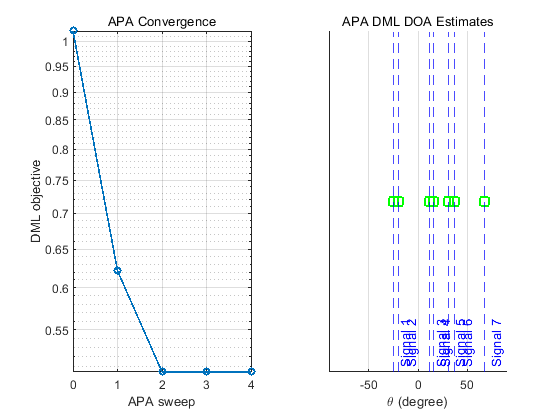

In [76]:
% APA method
theta_coarse = -90:1:90;
theta_fine = -90:0.1:90;
MLE_DOA_init = zeros(1, num_sources);

% Sequential initialization on a coarse grid
for i = 1:num_sources
    if i == 1
        P_ortho = eye(M);
    else
        A_neg_i = steering_vector(MLE_DOA_init(1:i-1));
        P_ortho = eye(M) - A_neg_i * pinv(A_neg_i);
    end

    A_scan = steering_vector(theta_coarse);
    Q = P_ortho * A_scan;
    q_norm_sq = sum(abs(Q).^2, 1);
    P_scan = real(sum(conj(Q) .* (R_xx * Q), 1) ./ max(q_norm_sq, eps));

    [~, peak_idx] = max(P_scan);
    MLE_DOA_init(i) = theta_coarse(peak_idx); % Store DOA, not grid index
end

max_iter = 200;
tol = 1e-3;
MLE_DOA = MLE_DOA_init;
% Evaluate the DML objective after the coarse initialization.
A_apa = steering_vector(MLE_DOA);
P_perp_apa = eye(M) - A_apa*pinv(A_apa);
cost_history_apa = nan(max_iter + 1, 1);
cost_history_apa(1) = norm(P_perp_apa*X, 'fro')^2/size(X, 2);

for iter = 1:max_iter
    DOAestimated_prev = MLE_DOA;
    for i = 1:num_sources
        % Remove the contribution of the other sources
        other_idx = [1:i-1, i+1:num_sources];
        A_neg_i = steering_vector(MLE_DOA(other_idx));
        P_neg_i = A_neg_i * pinv(A_neg_i);
        P_ortho = eye(M) - P_neg_i;

        A_scan = steering_vector(theta_fine);
        Q = P_ortho * A_scan;
        q_norm_sq = sum(abs(Q).^2, 1);
        P_scan = real(sum(conj(Q) .* (R_xx * Q), 1) ./ max(q_norm_sq, eps)); % calculating the trace of the matrix by verctorization method

        [~, peak_idx] = max(P_scan);
        MLE_DOA(i) = theta_fine(peak_idx); % Store DOA, not grid index
    end

    % Record the DML objective after one complete APA sweep.
    A_apa = steering_vector(MLE_DOA);
    P_perp_apa = eye(M) - A_apa*pinv(A_apa);
    cost_history_apa(iter + 1) = ...
        norm(P_perp_apa*X, 'fro')^2/size(X, 2);

    if max(abs(MLE_DOA - DOAestimated_prev)) < tol
        break;
    end
end

MLE_DOA = sort(MLE_DOA);
cost_history_apa = cost_history_apa(1:iter + 1);
fprintf('APA estimated angles (degrees), iterations = %d:\n', iter);
disp(MLE_DOA);
rmse_apa = sqrt(mean((MLE_DOA(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('APA RMSE = %.6f degrees\n', rmse_apa);

figure;
tiledlayout(1, 2);
nexttile;
semilogy(0:iter, max(cost_history_apa, eps), '-o', ...
    'LineWidth', 1.2, 'MarkerSize', 5);
grid on;
xlabel('APA sweep');
ylabel('DML objective');
title('APA Convergence');

nexttile;
hold on;
plot(MLE_DOA, zeros(size(MLE_DOA)), 'gs', 'MarkerSize', 8, 'LineWidth', 1.5);
grid on;
xlim([-90 90]);
ylim([-1 1]);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
xlabel('\theta (degree)');
yticks([]);
title('APA DML DOA Estimates');



##### 2. Gauss--Newton Method

Let $\mathbf{X}=\begin{bmatrix}\mathbf{x}(1)&\cdots&\mathbf{x}(N)\end{bmatrix}$ and $\hat{\mathbf{R}}_{xx}=\mathbf{X}\mathbf{X}^H/N$. For a trial DOA vector $\boldsymbol{\theta}$, define $\mathbf{A}=\mathbf{A}(\boldsymbol{\theta})$, $\mathbf{A}^{\dagger}=(\mathbf{A}^H\mathbf{A})^{-1}\mathbf{A}^H$, and the orthogonal projector

$$
\mathbf{P}_{\perp}(\boldsymbol{\theta})=\mathbf{I}-\mathbf{A}\mathbf{A}^{\dagger}.
$$

The DML criterion can be written as

$$
\begin{aligned}
f(\boldsymbol{\theta})
&=\operatorname{tr}\!\left(\mathbf{P}_{\perp}(\boldsymbol{\theta})\hat{\mathbf{R}}_{xx}\right)\\
&=\frac{1}{N}\left\lVert\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{X}\right\rVert_F^2.
\end{aligned}
$$

Therefore, an exactly equivalent nonlinear least-squares residual is

$$
\mathbf{r}(\boldsymbol{\theta})
=\frac{1}{\sqrt{N}}\operatorname{vec}\!\left(\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{X}\right),
\qquad
f(\boldsymbol{\theta})=\lVert\mathbf{r}(\boldsymbol{\theta})\rVert_2^2.
$$

Because $\boldsymbol{\theta}$ and its increment $\boldsymbol{\delta}$ are real, whereas $\mathbf{r}$ and $\mathbf{J}$ are complex, the Gauss--Newton step minimizes
$$
q_k(\boldsymbol{\delta})=\left\lVert\mathbf{r}^{(k)}+\mathbf{J}^{(k)}\boldsymbol{\delta}\right\rVert_2^2,
\qquad\boldsymbol{\delta}\in\mathbb{R}^K.
$$
Expanding this local least-squares objective gives
$$
q_k(\boldsymbol{\delta})=(\mathbf{r}^{(k)})^H\mathbf{r}^{(k)}
+2\boldsymbol{\delta}^T\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{r}^{(k)}\right)
+\boldsymbol{\delta}^T\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{J}^{(k)}\right)\boldsymbol{\delta}.
$$
Differentiating with respect to the real increment $\boldsymbol{\delta}$ gives
$$
\nabla_{\boldsymbol{\delta}}q_k
=2\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{r}^{(k)}\right)
+2\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{J}^{(k)}\right)\boldsymbol{\delta},
\qquad\nabla_{\boldsymbol{\delta}}^2q_k
=2\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{J}^{(k)}\right).
$$
Therefore, the real-parameter Gauss--Newton normal equation and update are
$$
\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{J}^{(k)}\right)\boldsymbol{\delta}^{(k)}
=-\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{r}^{(k)}\right),
$$
$$ 
\boldsymbol{\theta}^{(k+1)} = \boldsymbol{\theta}^{(k)}
-\left[\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{J}^{(k)}\right)\right]^{-1}
\operatorname{Re}\!\left((\mathbf{J}^{(k)})^H\mathbf{r}^{(k)}\right).
$$
where $\mathbf{J}(\boldsymbol{\theta})$ is the Jacobian matrix of $\mathbf{r}(\boldsymbol{\theta})$ with respect to $\boldsymbol{\theta}$. The Jacobian can be computed as
$$
\mathbf{J}(\boldsymbol{\theta}) = \frac{\partial \mathbf{r}(\boldsymbol{\theta})}{\partial \boldsymbol{\theta}} = \frac{1}{\sqrt{N}}\operatorname{vec}\!\left(\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \boldsymbol{\theta}}\mathbf{X}\right).
$$

For convenience, we shall first calculate the $i$-th column of the Jacobian matrix, which is given by
$$
\frac{\partial \mathbf{r}(\boldsymbol{\theta})}{\partial \theta_i} = \frac{1}{\sqrt{N}}\operatorname{vec}\!\left(\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i}\mathbf{X}\right).
$$

The derivative of the orthogonal projector $\mathbf{P}_{\perp}(\boldsymbol{\theta})$ with respect to $\theta_i$ can be computed as
$$
\begin{aligned}
\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i} 

&= -\frac{\partial \mathbf{P}(\boldsymbol{\theta})}{\partial \theta_i} \\
&= -\frac{\partial}{\partial \theta_i}\left(\mathbf{A}(\boldsymbol{\theta})\mathbf{A}^{\dagger}(\boldsymbol{\theta})\right) \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger}
- \mathbf{A}\frac{\partial \mathbf{A}^{\dagger}}{\partial \theta_i} \\

&=-\frac{\partial \mathbf{A}}{\partial \theta_i}(\mathbf{A}^H\mathbf{A})^{-1}\mathbf{A}^H
-\mathbf{A}\frac{\partial \left((\mathbf{A}^H\mathbf{A})^{-1}\mathbf{A}^H\right)}{\partial \theta_i} \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H
-\mathbf{A}\left[-\mathbf{G}^{-1}\frac{\partial \mathbf{G}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H + \mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}\right] \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H
+\mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{G}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H
-\mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}
\end{aligned}
$$

Because,
$$
\frac{\partial \mathbf{G}}{\partial \theta_i} = \frac{\partial (\mathbf{A}^H\mathbf{A})}{\partial \theta_i} = \frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{A} + \mathbf{A}^H\frac{\partial \mathbf{A}}{\partial \theta_i}
$$
Thus, the derivative of the orthogonal projector can be expressed as
$$
\begin{aligned}
\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i} 
&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H 
- \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i} 
+ \mathbf{A}\mathbf{G}^{-1}\left(\frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{A} 
+ \mathbf{A}^H\frac{\partial \mathbf{A}}{\partial \theta_i}\right)\mathbf{G}^{-1}\mathbf{A}^H \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H
- \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}
+ \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{A}\mathbf{G}^{-1}\mathbf{A}^H
+ \mathbf{A}\mathbf{G}^{-1}\mathbf{A}^H\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H
- \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}
+ \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{P}(\boldsymbol{\theta})
+ \mathbf{P}(\boldsymbol{\theta})\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{G}^{-1}\mathbf{A}^H \\

&= -\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger}
- \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}
+ \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{P}(\boldsymbol{\theta})
+ \mathbf{P}(\boldsymbol{\theta})\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger}\\

&= -\mathbf{P}_{\perp}(\boldsymbol{\theta})\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger}
- \mathbf{A}\mathbf{G}^{-1}\frac{\partial \mathbf{A}^H}{\partial \theta_i}\mathbf{P}_{\perp}(\boldsymbol{\theta})
\end{aligned}
$$

Because $\mathbf{A}\mathbf{G}^{-1} = \mathbf{A}(\mathbf{A}^H\mathbf{A})^{-1} = ((\mathbf{A}^H\mathbf{A})^{-1}\mathbf{A}^H)^H = (\mathbf{A}^{\dagger})^H$

So $\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i} = -\mathbf{P}_{\perp}(\boldsymbol{\theta})\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger} - (\mathbf{P}_{\perp}(\boldsymbol{\theta})\frac{\partial \mathbf{A}}{\partial \theta_i}\mathbf{A}^{\dagger})^H$

Notice that 
$$
\begin{aligned}
\frac{\partial \mathbf{A}}{\partial \theta_i} 
&= \begin{bmatrix}
\mathbf{0}_{M\times(i-1)} & \frac{\partial \mathbf{a}(\theta_i)}{\partial \theta_i} & \mathbf{0}_{M\times(K-i)}
\end{bmatrix} \\
\end{aligned}
$$

Let $\mathbf{p}=[0,d,\ldots,(M-1)d]^T$ denote the normalized sensor positions. Then
$$
\mathbf{d}_i
=\frac{\partial\mathbf{a}(\theta_i)}{\partial\theta_i}
=-j2\pi\cos(\theta_i)
\left(\mathbf{p}\odot\mathbf{a}(\theta_i)\right).
$$
Then we have

$$
\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i} = -\mathbf{P}_{\perp}(\boldsymbol{\theta})\begin{bmatrix}
\mathbf{0}_{M\times(i-1)} & \mathbf{d}_i & \mathbf{0}_{M\times(K-i)}
\end{bmatrix}\mathbf{A}^{\dagger} - \left(\mathbf{P}_{\perp}(\boldsymbol{\theta})\begin{bmatrix}
\mathbf{0}_{M\times(i-1)} & \mathbf{d}_i & \mathbf{0}_{M\times(K-i)}
\end{bmatrix}\mathbf{A}^{\dagger}\right)^H
$$

Define the basis vector $\mathbf{e}_i$ as the $i$-th column of the identity matrix $\mathbf{I}_K$. Then we can express the derivative of the orthogonal projector as
$$
\frac{\partial \mathbf{P}_{\perp}(\boldsymbol{\theta})}{\partial \theta_i} = -\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{d}_i\mathbf{e}_i^T\mathbf{A}^{\dagger} - \left(\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{d}_i\mathbf{e}_i^T\mathbf{A}^{\dagger}\right)^H
$$

So the $i$-th column of the Jacobian matrix can be computed as
$$
\frac{\partial \mathbf{r}(\boldsymbol{\theta})}{\partial \theta_i}
=\frac{1}{\sqrt{N}}\operatorname{vec}\!\left(
\left[-\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{d}_i\mathbf{e}_i^T\mathbf{A}^{\dagger}
-\left(\mathbf{P}_{\perp}(\boldsymbol{\theta})\mathbf{d}_i\mathbf{e}_i^T\mathbf{A}^{\dagger}\right)^H\right]\mathbf{X}
\right).
$$

Gauss--Newton estimated angles (degrees), updates = 10, converged = 1:
  -25.0899  -19.2617   11.6762   15.3974   30.6037   37.2373   66.7845

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

Gauss--Newton RMSE = 0.045201 degrees


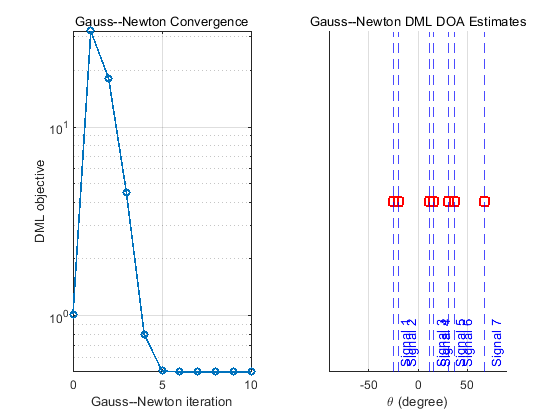

In [77]:
% ===== Updated formula-matched Gauss--Newton implementation =====
% Jacobian chain: d_i -> A_i=d_i*e_i^T -> P_perp_i -> J(:,i)
% Original Gauss--Newton only: no LM damping and no line search
% Run the signal-generation and APA cells before running this cell.
assert(exist('MLE_DOA_init', 'var') == 1 && numel(MLE_DOA_init) == num_sources, ...
    'Run the APA cell first to obtain the common initial estimate.');

GN_DOA = sort(MLE_DOA_init(:));       % APA initialization, K-by-1 (degrees)
K_gn = numel(GN_DOA);
N_gn = size(X, 2);
sqrt_N = sqrt(N_gn);
I_M = eye(M);
I_K = eye(K_gn);

max_iter_gn = 100;
tol_theta_gn = 1e-6;             % degree
tol_cost_gn = 1e-10;
tol_gradient_gn = 1e-8;
cost_history_gn = nan(max_iter_gn + 1, 1);
num_updates_gn = 0;
converged_gn = false;

for iter_gn = 1:max_iter_gn
    %% 1. Residual r(theta) = vec(P_perp(theta)*X)/sqrt(N)
    A_gn = steering_vector(GN_DOA.');
    G_gn = A_gn'*A_gn;
    if rcond(G_gn) < 1e-12
        warning('GaussNewton:RankDeficientManifold', ...
            'A^H*A is nearly singular at iteration %d.', iter_gn);
    end
    G_inv = G_gn \ I_K;          % G^{-1}, obtained by a linear solve
    A_dag = G_inv*A_gn';          % A^dagger = G^{-1}*A^H
    P_perp = I_M - A_gn*G_inv*A_gn';
    E_gn = P_perp*X/sqrt_N;
    r_gn = E_gn(:);
    cost_gn = real(r_gn'*r_gn);
    if iter_gn == 1
        cost_history_gn(1) = cost_gn;
    end

    %% 2. Jacobian derived from d_i*e_i^T and dP_perp/dtheta_i
    J_gn = complex(zeros(M*N_gn, K_gn));
    for ii = 1:K_gn
        % d_i = partial a(theta_i)/partial theta_i.
        % position=(0:M-1)'*d and theta is stored in degrees.
        d_i = -1j*2*pi*(pi/180)*cosd(GN_DOA(ii)) ...
            .* position .* A_gn(:, ii);

        % e_i is column i of I_K, so A_i=d_i*e_i^T.
        e_i = I_K(:, ii);
        A_i = d_i*e_i.';

        % C_i=P_perp*d_i*e_i^T*A^dagger.
        % Therefore P_perp_i=-C_i-C_i^H.
        C_i = P_perp*d_i*e_i.'*A_dag;
        P_perp_i = -C_i - C_i';

        % J(:,i)=vec(P_perp_i*X)/sqrt(N).
        % X multiplies the complete projector derivative.
        E_i = P_perp_i*X/sqrt_N;
        J_gn(:, ii) = E_i(:);
    end

    %% 3. Terms J^H*J and J^H*r in the written GN formula
    JHJ_gn = J_gn'*J_gn;
    JHr_gn = J_gn'*r_gn;

    % GN_DOA is real. For complex J and r, the corresponding
    % real-parameter normal equation uses the real parts.
    H_gn = real(JHJ_gn);
    H_gn = (H_gn + H_gn.')/2;
    g_gn = real(JHr_gn);
    gradient_gn = 2*g_gn;
    Hessian_gn = 2*H_gn; %#ok<NASGU> % explicit GN Hessian

    if norm(gradient_gn, inf) < tol_gradient_gn
        converged_gn = true;
        break;
    end

    %% 4. Original full Gauss--Newton step
    % H*delta_GN = -g, where H=Re(J^H*J), g=Re(J^H*r).
    delta_gn = -H_gn \ g_gn;
    if any(~isfinite(delta_gn))
        warning('GaussNewton:InvalidStep', ...
            'The Gauss--Newton step is not finite at iteration %d.', iter_gn);
        break;
    elseif norm(delta_gn, inf) < tol_theta_gn
        converged_gn = true;
        break;
    end

    %% 5. Update theta^(k+1) = theta^(k) + delta_GN
    GN_DOA = GN_DOA + delta_gn;
    A_trial = steering_vector(GN_DOA.');
    G_trial = A_trial'*A_trial;
    G_trial_inv = G_trial \ I_K;
    P_trial = I_M - A_trial*G_trial_inv*A_trial';
    E_trial = P_trial*X/sqrt_N;
    r_trial = E_trial(:);
    cost_trial = real(r_trial'*r_trial);
    relative_change = abs(cost_gn - cost_trial)/max(cost_gn, eps);
    num_updates_gn = num_updates_gn + 1;
    cost_history_gn(num_updates_gn + 1) = cost_trial;

    if relative_change < tol_cost_gn
        converged_gn = true;
        break;
    end
end

GN_DOA = sort(GN_DOA).';
cost_history_gn = cost_history_gn(1:num_updates_gn + 1);
fprintf('Gauss--Newton estimated angles (degrees), updates = %d, converged = %d:\n', ...
    num_updates_gn, converged_gn);
disp(GN_DOA);
rmse_gn = sqrt(mean((GN_DOA(:).' - sort(theta(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(theta(:).'));
fprintf('Gauss--Newton RMSE = %.6f degrees\n', rmse_gn);

figure;
tiledlayout(1, 2);
nexttile;
semilogy(0:num_updates_gn, max(cost_history_gn, eps), '-o', ...
    'LineWidth', 1.2, 'MarkerSize', 5);
grid on;
xlabel('Gauss--Newton iteration');
ylabel('DML objective');
title('Gauss--Newton Convergence');

nexttile;
hold on;
plot(GN_DOA, zeros(size(GN_DOA)), 'rs', ...
    'MarkerSize', 8, 'LineWidth', 1.5);
for ii = 1:numel(theta)
    xline(theta(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
grid on;
xlim([-90 90]);
ylim([-1 1]);
xlabel('\theta (degree)');
yticks([]);
title('Gauss--Newton DML DOA Estimates');


##### 3. Expectation-Maximization(EM) Algorithm

EM algorithm is a well known iterative method for finding maximum likelihood estimates of parameters in statistical models, where the model depends on unobserved latent variables. In the context of DOA estimation, the EM algorithm can be applied to estimate the parameters of interest (e.g., angles of arrival) by treating the source signals as latent variables.

First, I shall give a brief overview of the EM algorithm. EM algorithm consists of two main steps: the Expectation (E) step and the Maximization (M) step. In the E-step, we compute the expected value of the log-likelihood function with respect to the latent variables, given the current estimates of the parameters. In the M-step, we maximize this expected log-likelihood with respect to the parameters to obtain updated estimates.

Suppose we have a set of observed data $\mathbf{X}$ and a set of latent variables $\mathbf{Z}$, and we want to estimate the parameters $\boldsymbol{\theta}$ of the model. The complete data log-likelihood is given by $\ln p(\mathbf{X}, \mathbf{Z}; \boldsymbol{\theta})$. 
Our goal is to obtain the parameter estimates that maximize the marginal likelihood of the observed data, which is given by $\ln p(\mathbf{X}; \boldsymbol{\theta}) = \ln \int p(\mathbf{X}, \mathbf{Z}; \boldsymbol{\theta}) d\mathbf{Z}$. Considering discrete latent variables, and applying maximum likelihood estimation
$$
\hat{\boldsymbol{\theta}} = \arg\max_{\boldsymbol{\theta}} \sum_{i}\ln p(x_i; \boldsymbol{\theta}) = \arg\max_{\boldsymbol{\theta}}   \sum_{i}\ln \sum_{j} p(x_i, z_j; \boldsymbol{\theta})
$$
We cannot sovle this problem directly using derivatives because of the summation inside the logarithm. So we introduce a variational distribution $q_i(z_j)$ to approximate the posterior distribution of the latent variables, where we define $\sum_{j} q_i(z_j) = 1$. So we can rewrite the log-likelihood as
$$
\ln p(x_i; \boldsymbol{\theta}) = \ln \sum_{j} q_i(z_j) \frac{p(x_i, z_j; \boldsymbol{\theta})}{q_i(z_j)} \geq \sum_{j} q_i(z_j) \ln \frac{p(x_i, z_j; \boldsymbol{\theta})}{q_i(z_j)}
$$
The inequality is due to Jensen's inequality, which will be explained in Appendix. Thus we can keep maximizing the lower bound of the log-likelihood function $\sum_{i}\sum_{j} q_i(z_j) \ln \frac{p(x_i, z_j; \boldsymbol{\theta})}{q_i(z_j)}$ instead of the original log-likelihood function.

According to the equality condition of Jensen's inequality, the lower bound is tight if the argument of the logarithm is constant for every $z_j$ in the support of $q_i$, i.e.,
$$
\frac{p(x_i, z_j; \boldsymbol{\theta})}{q_i(z_j)} = \text{constant} \quad \text{for every }j\text{ such that }q_i(z_j)>0.
$$
Multiplying both sides by $q_i(z_j)$ and summing over $j$ gives
$$
\text{constant}=\sum_j p(x_i,z_j;\boldsymbol{\theta})=p(x_i;\boldsymbol{\theta}).
$$
Thus we can obtain the optimal variational distribution $q_i(z_j)$ as the posterior distribution of the latent variables given the observed data and current parameter estimates by applying Bayes' theorem:
$$
q_i(z_j) = \frac{p(x_i, z_j; \boldsymbol{\theta})}{\sum_{j'} p(x_i, z_{j'}; \boldsymbol{\theta})} = p(z_j|x_i; \boldsymbol{\theta})
$$
So 
$$
\ln p(x_i; \boldsymbol{\theta})  \geq \sum_{j} p(z_j|x_i; \boldsymbol{\theta}) \ln \frac{p(x_i, z_j; \boldsymbol{\theta})}{p(z_j|x_i; \boldsymbol{\theta})} 
$$

Thus we have the E-step of the EM algorithm. Starting from an initial estimate $\boldsymbol{\theta}^{(0)}$, we number the iterations so that the $k$-th E-step uses $\boldsymbol{\theta}^{(k-1)}$ and the subsequent M-step produces $\boldsymbol{\theta}^{(k)}$. Therefore,
$$
q_i^{(k)}(z_j) = p(z_j|x_i; \boldsymbol{\theta}^{(k-1)}).
$$

Next, we have the M-step, where we maximize the expected log-likelihood with respect to the parameters:
$$
\begin{aligned}
\boldsymbol{\theta}^{(k)} &= \arg\max_{\boldsymbol{\theta}} \sum_{i}\sum_{j} q_i^{(k)}(z_j) \ln \frac{p(x_i, z_j; \boldsymbol{\theta})}{q_i^{(k)}(z_j)} \\
&= \arg\max_{\boldsymbol{\theta}} \sum_{i}\sum_{j} \{q_i^{(k)}(z_j) \ln p(x_i, z_j; \boldsymbol{\theta}) - q_i^{(k)}(z_j) \ln q_i^{(k)}(z_j) \}
\end{aligned}
$$
The term $- q^{(k)}(z_j) \ln q^{(k)}(z_j)$ does not depend on $\boldsymbol{\theta}$, so we can ignore it in the maximization step. Thus, the M-step simplifies to
$$
\boldsymbol{\theta}^{(k)} = \arg\max_{\boldsymbol{\theta}} \sum_{i}\sum_{j} q_i^{(k)}(z_j) \ln p(x_i, z_j; \boldsymbol{\theta})
$$
This is the conditional expectation of the complete data log-likelihood, so we can simplify E-step and M-step as follows:
- E-step: Compute the expected value of the complete data log-likelihood with respect to the current estimate of the parameters:
$$
Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{(k-1)}) = \sum_{i}\sum_{j} p(z_j|x_i; \boldsymbol{\theta}^{(k-1)}) \ln p(x_i, z_j; \boldsymbol{\theta})
$$
- M-step: Maximize this expected log-likelihood with respect to the parameters to obtain updated estimates:
$$
\boldsymbol{\theta}^{(k)} = \arg\max_{\boldsymbol{\theta}} Q(\boldsymbol{\theta}|\boldsymbol{\theta}^{(k-1)})
$$


In DML problem, and we have 
$$
\mathbf{x}(n) = \mathbf{A}(\boldsymbol{\theta})\mathbf{s}(n) + \mathbf{n}(n)
$$
where, $\mathbf{n}(n) \sim \mathcal{CN}(\mathbf{0}, \sigma^2 \mathbf{I})$ is the complex Gaussian noise.
The latent variables are the contributions of the individual sources to the received signal, $\mathbf{y}_l(n)=\mathbf{a}(\theta_l)s_l(n)+\mathbf{n}_l(n)$, where the artificial component noises $\mathbf{n}_l(n)$ are mutually independent. We use equal noise allocation,
$$
\beta_l=\frac{1}{L},\qquad \sigma_l^2=\frac{\sigma^2}{L},\qquad l=1,\ldots,L.
$$
Therefore, $\mathbf{n}_l(n)\sim\mathcal{CN}(\mathbf{0},(\sigma^2/L)\mathbf{I}_M)$ and $\mathbf{y}_l(n)\sim\mathcal{CN}(\mathbf{a}(\theta_l)s_l(n),(\sigma^2/L)\mathbf{I}_M)$. The shared total noise variance $\sigma^2$ is the free noise parameter, and each component variance is fixed by $\sigma_l^2=\sigma^2/L$. Define $\boldsymbol{\vartheta}=\{\boldsymbol{\theta},\mathbf{S},\sigma^2\}$. The observed data satisfy $\mathbf{x}(n)=\sum_{l=1}^L\mathbf{y}_l(n)$. The maximum-likelihood problem is
$$
\boldsymbol{\hat{\vartheta}} = \arg\max_{\boldsymbol{\vartheta}} p(\mathbf{x}(1),\ldots,\mathbf{x}(N); \boldsymbol{\vartheta}) 
$$


If we actually observed each latent variable $\mathbf{y}_l(n)$, the complete data likelihood function would be
$$
p(\mathbf{Y};\boldsymbol{\vartheta}) = \prod_{l=1}^L \prod_{n=1}^N \frac{1}{\pi^M(\sigma^2/L)^M} \exp\left(-\frac{L}{\sigma^2}\|\mathbf{y}_l(n) - \mathbf{a}(\theta_l)s_l(n)\|_2^2\right).
$$

The log-likelihood function of the complete data is then given by
$$
\ln p(\mathbf{Y};\boldsymbol{\vartheta}) = -NML\ln\left(\frac{\pi\sigma^2}{L}\right) - \frac{L}{\sigma^2}\sum_{l=1}^L\sum_{n=1}^N \|\mathbf{y}_l(n) - \mathbf{a}(\theta_l)s_l(n)\|_2^2.
$$

The latent variables $\mathbf{y}_l(n)$ are not observed. Denote the observed data by $\mathbf{X}=[\mathbf{x}(1),\mathbf{x}(2),\ldots,\mathbf{x}(N)]$, define $\mathbf{Y}_l=[\mathbf{y}_l(1),\mathbf{y}_l(2),\ldots,\mathbf{y}_l(N)]$, and let $\mathbf{Y}=\{\mathbf{Y}_1,\ldots,\mathbf{Y}_L\}$.

Normally, the E-step is to compute
$$
Q(\boldsymbol{\vartheta}|\boldsymbol{\vartheta}^{(k-1)}) = \mathbb{E}_{\mathbf{Y}|\mathbf{X}; \boldsymbol{\vartheta}^{(k-1)}}[\ln p(\mathbf{X},\mathbf{Y}; \boldsymbol{\vartheta})]
$$
Here $\mathbf{X}=H(\mathbf{Y})$, where $H$ is the deterministic summation map defined by $\mathbf{x}(n)=\sum_{l=1}^L\mathbf{y}_l(n)$. Because this observation map contains no unknown parameter, the parameter-dependent part of the EM auxiliary function can be written directly as
$$
Q(\boldsymbol{\vartheta}|\boldsymbol{\vartheta}^{(k-1)}) = \mathbb{E}_{\mathbf{Y}|\mathbf{X}; \boldsymbol{\vartheta}^{(k-1)}}\{\ln p(\mathbf{Y};\boldsymbol{\vartheta})\} 
$$
The complete-data density factorizes over sources and snapshots before conditioning, so its logarithm is additive. Moreover, snapshot independence implies $p(\mathbf{y}_l(n)\mid\mathbf{X};\boldsymbol{\vartheta}^{(k-1)})=p(\mathbf{y}_l(n)\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)})$. By linearity of conditional expectation, the function $Q$ can therefore be written as
$$
\begin{aligned}
Q(\boldsymbol{\vartheta}|\boldsymbol{\vartheta}^{(k-1)})
&= \sum_{l=1}^L \sum_{n=1}^N \mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n); \boldsymbol{\vartheta}^{(k-1)}}\{\ln p(\mathbf{y}_l(n); \boldsymbol{\vartheta}_l)\} \\
&= -NML\ln\left(\frac{\pi\sigma^2}{L}\right)-\frac{L}{\sigma^2}\sum_{l=1}^L\sum_{n=1}^N \mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n); \boldsymbol{\vartheta}^{(k-1)}}\{\|\mathbf{y}_l(n) - \mathbf{a}(\theta_l)s_l(n)\|_2^2\} \\

\end{aligned}
$$

Because $\mathbf{x}(n)=\sum_{r=1}^L\mathbf{y}_r(n)$, we now prove that $\mathbf{x}(n)$ and $\mathbf{y}_l(n)$ are jointly Gaussian.

For a fixed snapshot $n$, the distribution used in the $k$-th E-step is evaluated at the previous parameter estimate $\boldsymbol{\vartheta}^{(k-1)}$. In particular,
$$
\begin{aligned}
\boldsymbol{\mu}_r^{(k-1)}(n)
&=\mathbb{E}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_r(n)]\\
&=\mathbf{a}(\theta_r^{(k-1)})s_r^{(k-1)}(n),\\
(\sigma_r^2)^{(k-1)}&=\frac{(\sigma^2)^{(k-1)}}{L}.
\end{aligned}
$$
The artificial complete-data construction assumes that the component noises, and hence the vectors $\mathbf{y}_r(n)$, are mutually independent across $r$. Therefore, the stacked vector
$$
\mathbf{y}(n)
=\begin{bmatrix}\mathbf{y}_1^T(n)&\cdots&\mathbf{y}_L^T(n)\end{bmatrix}^T
$$
is proper complex Gaussian:
$$
\mathbf{y}(n)\sim\mathcal{CN}\!\left(
\begin{bmatrix}
\mathbf{a}(\theta_1^{(k-1)})s_1^{(k-1)}(n)\\
\vdots\\
\mathbf{a}(\theta_L^{(k-1)})s_L^{(k-1)}(n)
\end{bmatrix},
\begin{bmatrix}
(\sigma_1^2)^{(k-1)}\mathbf{I}_M&\mathbf{0}&\cdots&\mathbf{0}\\
\mathbf{0}&(\sigma_2^2)^{(k-1)}\mathbf{I}_M&\cdots&\mathbf{0}\\
\vdots&\vdots&\ddots&\vdots\\
\mathbf{0}&\mathbf{0}&\cdots&(\sigma_L^2)^{(k-1)}\mathbf{I}_M
\end{bmatrix}
\right).
$$
Both $\mathbf{y}_l(n)$ and $\mathbf{x}(n)=\sum_{r=1}^L\mathbf{y}_r(n)$ are linear functions of this same Gaussian vector. More explicitly, with $\mathbf{e}_l$ denoting the $l$-th canonical basis vector in $\mathbb{R}^L$,
$$
\begin{bmatrix}\mathbf{y}_l(n)\\\mathbf{x}(n)\end{bmatrix}
=
\begin{bmatrix}
\mathbf{e}_l^T\otimes\mathbf{I}_M\\
\mathbf{1}_L^T\otimes\mathbf{I}_M
\end{bmatrix}
\mathbf{y}(n).
$$
Since every deterministic linear transformation of a proper complex Gaussian vector is again proper complex Gaussian, $\mathbf{y}_l(n)$ and $\mathbf{x}(n)$ are jointly proper complex Gaussian. This conclusion does **not** follow merely because each marginal vector is Gaussian; the common affine representation above is the required argument.

Define the DOA vector, source vector, and array manifold matrix evaluated at the $(k-1)$-th parameter estimate as
$$
\begin{aligned}
\boldsymbol{\theta}^{(k-1)}
&=\begin{bmatrix}\theta_1^{(k-1)}&\cdots&\theta_L^{(k-1)}\end{bmatrix}^T,\\
\mathbf{s}^{(k-1)}(n)
&=\begin{bmatrix}s_1^{(k-1)}(n)&\cdots&s_L^{(k-1)}(n)\end{bmatrix}^T,\\
\mathbf{A}(\boldsymbol{\theta}^{(k-1)})
&=\begin{bmatrix}
\mathbf{a}(\theta_1^{(k-1)})&\cdots&\mathbf{a}(\theta_L^{(k-1)})
\end{bmatrix}.
\end{aligned}
$$
Their means in the $k$-th E-step are
$$
\begin{aligned}
\mathbb{E}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n)]
&=\mathbf{a}(\theta_l^{(k-1)})s_l^{(k-1)}(n),\\
\mathbb{E}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{x}(n)]
&=\mathbf{A}(\boldsymbol{\theta}^{(k-1)})\mathbf{s}^{(k-1)}(n).
\end{aligned}
$$
Independence of the artificial component noises gives
$$
\begin{aligned}
\operatorname{Cov}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n)]
&=\frac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M,\\
\operatorname{Cov}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{x}(n)]
&=\sum_{r=1}^L(\sigma_r^2)^{(k-1)}\mathbf{I}_M
=(\sigma^2)^{(k-1)}\mathbf{I}_M,\\
\operatorname{Cov}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n),\mathbf{x}(n)]
&=\mathbb{E}\!\left[(\mathbf{y}_l(n)-\boldsymbol{\mu}_l^{(k-1)}(n))
\left(\sum_{r=1}^L(\mathbf{y}_r(n)-\boldsymbol{\mu}_r^{(k-1)}(n))\right)^H\right]\\
&=\sum_{r=1}^L\operatorname{Cov}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n),\mathbf{y}_r(n)]\\
&=\frac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M.
\end{aligned}
$$
Consequently,
$$
\boxed{
\begin{bmatrix}\mathbf{y}_l(n)\\\mathbf{x}(n)\end{bmatrix}
\sim\mathcal{CN}\!\left(
\begin{bmatrix}
\mathbf{a}(\theta_l^{(k-1)})s_l^{(k-1)}(n)\\
\mathbf{A}(\boldsymbol{\theta}^{(k-1)})\mathbf{s}^{(k-1)}(n)
\end{bmatrix},
\begin{bmatrix}
\dfrac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M
&\dfrac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M\\
\dfrac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M
&\displaystyle\sum_{r=1}^L(\sigma_r^2)^{(k-1)}\mathbf{I}_M
\end{bmatrix}
\right).}
$$
Since $\sum_{r=1}^L(\sigma_r^2)^{(k-1)}=(\sigma^2)^{(k-1)}$, the lower-right block may equivalently be written as $(\sigma^2)^{(k-1)}\mathbf{I}_M$. The lower-left block is the Hermitian transpose of the upper-right block and is equal to it here. The joint pseudo-covariance is zero because the component vectors are proper. This proves that $\mathbf{x}(n)$ and $\mathbf{y}_l(n)$ are jointly proper complex Gaussian.

For the conditional expectation in $Q$, denote the candidate mean to be optimized in the M-step by
$$
\boldsymbol{\mu}_l(n)=\mathbf{a}(\theta_l)s_l(n)\in\mathbb{C}^{M\times1}.
$$
It is a complex column vector, not a scalar. Its Hermitian transpose is $\boldsymbol{\mu}_l^H(n)\in\mathbb{C}^{1\times M}$. Denote the conditional mean computed in the $k$-th E-step by
$$
\begin{aligned}
\widehat{\mathbf{y}}_l^{(k)}(n)
&=\mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n)]\\
&=\mathbf{a}(\theta_l^{(k-1)})s_l^{(k-1)}(n)
+\frac{1}{L}\left[\mathbf{x}(n)-\mathbf{A}(\boldsymbol{\theta}^{(k-1)})\mathbf{s}^{(k-1)}(n)\right],
\end{aligned}
$$
The corresponding conditional covariance is
$$
\begin{aligned}
\mathbf{C}_l^{(k)}
&=\operatorname{Cov}_{\boldsymbol{\vartheta}^{(k-1)}}[\mathbf{y}_l(n)\mid\mathbf{x}(n)]\\
&=\frac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M
-\frac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M
\left[(\sigma^2)^{(k-1)}\mathbf{I}_M\right]^{-1}
\frac{(\sigma^2)^{(k-1)}}{L}\mathbf{I}_M\\
&=\frac{L-1}{L^2}(\sigma^2)^{(k-1)}\mathbf{I}_M.
\end{aligned}
$$
To expand the conditional second moment without skipping steps, first use $\mathbf{y}_l^H(n)\mathbf{y}_l(n)=\operatorname{tr}[\mathbf{y}_l(n)\mathbf{y}_l^H(n)]$:
$$
\begin{aligned}
&\mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}}
\!\left[\mathbf{y}_l^H(n)\mathbf{y}_l(n)\right]\\
&=\mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}}
\!\left[\operatorname{tr}\!\left(\mathbf{y}_l(n)\mathbf{y}_l^H(n)\right)\right]\\
&=\operatorname{tr}\!\left(
\mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}}
\!\left[\mathbf{y}_l(n)\mathbf{y}_l^H(n)\right]\right).
\end{aligned}
$$
By the definition of conditional covariance,
$$
\begin{aligned}
\mathbf{C}_l^{(k)}
&=\mathbb{E}\!\left[
\left(\mathbf{y}_l(n)-\widehat{\mathbf{y}}_l^{(k)}(n)\right)
\left(\mathbf{y}_l(n)-\widehat{\mathbf{y}}_l^{(k)}(n)\right)^H
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}\right]\\
&=\mathbb{E}\!\left[
\mathbf{y}_l(n)\mathbf{y}_l^H(n)
-\mathbf{y}_l(n)\widehat{\mathbf{y}}_l^{(k)H}(n)
-\widehat{\mathbf{y}}_l^{(k)}(n)\mathbf{y}_l^H(n)
+\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}\right]\\
&=\mathbb{E}\!\left[\mathbf{y}_l(n)\mathbf{y}_l^H(n)
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}\right]
-\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)
-\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)
+\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)\\
&=\mathbb{E}\!\left[\mathbf{y}_l(n)\mathbf{y}_l^H(n)
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}\right]
-\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n).
\end{aligned}
$$
Here we used
$$
\mathbb{E}[\mathbf{y}_l(n)\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}]
=\widehat{\mathbf{y}}_l^{(k)}(n)
$$
and its Hermitian transpose. Rearranging the covariance identity gives
$$
\mathbb{E}\!\left[\mathbf{y}_l(n)\mathbf{y}_l^H(n)
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}\right]
=\mathbf{C}_l^{(k)}
+\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n).
$$
Substitution into the trace expression yields
$$
\begin{aligned}
&\mathbb{E}[\mathbf{y}_l^H(n)\mathbf{y}_l(n)
\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}]\\
&=\operatorname{tr}\!\left(\mathbf{C}_l^{(k)}
+\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)\right)\\
&=\operatorname{tr}(\mathbf{C}_l^{(k)})
+\operatorname{tr}\!\left(
\widehat{\mathbf{y}}_l^{(k)}(n)\widehat{\mathbf{y}}_l^{(k)H}(n)\right)\\
&=\operatorname{tr}(\mathbf{C}_l^{(k)})
+\widehat{\mathbf{y}}_l^{(k)H}(n)\widehat{\mathbf{y}}_l^{(k)}(n)\\
&=M\frac{L-1}{L^2}(\sigma^2)^{(k-1)}
+\left\|\widehat{\mathbf{y}}_l^{(k)}(n)\right\|_2^2.
\end{aligned}
$$
Using the conditional mean and covariance, the required conditional quadratic error is
$$
\begin{aligned}
&\mathbb{E}_{\mathbf{y}_l(n)|\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}}
\!\left[\|\mathbf{y}_l(n)-\boldsymbol{\mu}_l(n)\|_2^2\right]\\
&=\operatorname{tr}(\mathbf{C}_l^{(k)})
+\left\|\widehat{\mathbf{y}}_l^{(k)}(n)-\boldsymbol{\mu}_l(n)\right\|_2^2\\
&=M\frac{L-1}{L^2}(\sigma^2)^{(k-1)}
+\left\|\widehat{\mathbf{y}}_l^{(k)}(n)-\mathbf{a}(\theta_l)s_l(n)\right\|_2^2.
\end{aligned}
$$
Substituting this result into the auxiliary function removes the conditional expectation:
$$
\begin{aligned}
Q(\boldsymbol{\vartheta}|\boldsymbol{\vartheta}^{(k-1)})
&=-NML\ln\left(\frac{\pi\sigma^2}{L}\right)
-NM(L-1)\frac{(\sigma^2)^{(k-1)}}{\sigma^2}\\
&\quad-\frac{L}{\sigma^2}\sum_{l=1}^L\sum_{n=1}^N
\left\|\widehat{\mathbf{y}}_l^{(k)}(n)-\mathbf{a}(\theta_l)s_l(n)\right\|_2^2.
\end{aligned}
$$
For fixed $\sigma^2$, maximizing $Q$ with respect to $\theta_l$ and $s_l(n)$ is therefore equivalent, for each source $l$, to minimizing $\sum_{n=1}^N\|\widehat{\mathbf{y}}_l^{(k)}(n)-\mathbf{a}(\theta_l)s_l(n)\|_2^2$.

For fixed $\theta_l$, maximizing $Q_l$ with respect to the deterministic complex amplitude $s_l(n)$ is a least-squares problem. Its solution is
$$
s_l^{(k)}(n;\theta_l)=\frac{\mathbf{a}^H(\theta_l)\widehat{\mathbf{y}}_l^{(k)}(n)}{\mathbf{a}^H(\theta_l)\mathbf{a}(\theta_l)}.
$$
Define
$$
\mathbf{P}_{a}(\theta)=\frac{\mathbf{a}(\theta)\mathbf{a}^H(\theta)}{\mathbf{a}^H(\theta)\mathbf{a}(\theta)},\qquad \mathbf{P}_{a}^{\perp}(\theta)=\mathbf{I}_M-\mathbf{P}_{a}(\theta).
$$
After concentrating out the amplitudes, the angle update is
$$
\boxed{\theta_l^{(k)}=\underset{\theta\in\Theta}{\arg\min}\;\sum_{n=1}^N\left\|\mathbf{P}_{a}^{\perp}(\theta)\widehat{\mathbf{y}}_l^{(k)}(n)\right\|_2^2.}
$$
Define
$$
\widehat{\mathbf{Y}}_l^{(k)}=\begin{bmatrix}\widehat{\mathbf{y}}_l^{(k)}(1)&\cdots&\widehat{\mathbf{y}}_l^{(k)}(N)\end{bmatrix},\qquad \widehat{\mathbf{R}}_{y_l}^{(k)}=\frac{1}{N}\widehat{\mathbf{Y}}_l^{(k)}\widehat{\mathbf{Y}}_l^{(k)H}.
$$
Since
$$
\sum_{n=1}^N\left\|\mathbf{P}_{a}^{\perp}(\theta)\widehat{\mathbf{y}}_l^{(k)}(n)\right\|_2^2=\sum_{n=1}^N\left\|\widehat{\mathbf{y}}_l^{(k)}(n)\right\|_2^2-N\frac{\mathbf{a}^H(\theta)\widehat{\mathbf{R}}_{y_l}^{(k)}\mathbf{a}(\theta)}{\mathbf{a}^H(\theta)\mathbf{a}(\theta)},
$$
the equivalent angle update is
$$
\boxed{\theta_l^{(k)}=\underset{\theta\in\Theta}{\arg\max}\;\frac{\mathbf{a}^H(\theta)\widehat{\mathbf{R}}_{y_l}^{(k)}\mathbf{a}(\theta)}{\mathbf{a}^H(\theta)\mathbf{a}(\theta)}.}
$$
The angle $\theta_l$ is real, so Wirtinger differentiation is not applicable. This one-dimensional maximization can be performed by a grid search or a real-variable optimizer. After obtaining $\theta_l^{(k)}$, update the amplitude by
$$
\boxed{s_l^{(k)}(n)=\frac{\mathbf{a}^H(\theta_l^{(k)})\widehat{\mathbf{y}}_l^{(k)}(n)}{\mathbf{a}^H(\theta_l^{(k)})\mathbf{a}(\theta_l^{(k)})},\qquad n=1,\ldots,N.}
$$
To update the shared total noise variance, define the total post-update residual energy as
$$
\mathcal{E}^{(k)}=\sum_{l=1}^L\sum_{n=1}^N\left\|\widehat{\mathbf{y}}_l^{(k)}(n)-\mathbf{a}(\theta_l^{(k)})s_l^{(k)}(n)\right\|_2^2.
$$
Let $v=\sigma^2>0$ denote the candidate total variance. The variance-dependent part of $Q$ is
$$
Q_{\sigma}^{(k)}(v)=-NML\ln\left(\frac{\pi v}{L}\right)-\frac{NM(L-1)(\sigma^2)^{(k-1)}+L\mathcal{E}^{(k)}}{v}.
$$
Therefore,
$$
\frac{dQ_{\sigma}^{(k)}(v)}{dv}=-\frac{NML}{v}+\frac{NM(L-1)(\sigma^2)^{(k-1)}+L\mathcal{E}^{(k)}}{v^2}.
$$
Setting the derivative to zero gives
$$
\boxed{(\sigma^2)^{(k)}=\frac{L-1}{L}(\sigma^2)^{(k-1)}+\frac{\mathcal{E}^{(k)}}{NM}.}
$$
The component variances remain equally allocated:
$$
\boxed{(\sigma_l^2)^{(k)}=\frac{(\sigma^2)^{(k)}}{L},\qquad l=1,\ldots,L.}
$$

#### EM algorithm summary

Let $M$ be the number of sensors, $N$ the number of snapshots, and $L$ the number of sources. Given the initial DOA vector
$$
\boldsymbol{\theta}^{(0)}=\begin{bmatrix}\theta_1^{(0)}&\cdots&\theta_L^{(0)}\end{bmatrix}^T,
$$
form the initial array manifold matrix
$$
\mathbf{A}^{(0)}=\mathbf{A}(\boldsymbol{\theta}^{(0)})
=\begin{bmatrix}\mathbf{a}(\theta_1^{(0)})&\cdots&\mathbf{a}(\theta_L^{(0)})\end{bmatrix}.
$$
Initialize the deterministic source matrix by least squares:
$$
\boxed{\mathbf{S}^{(0)}=(\mathbf{A}^{(0)})^{\dagger}\mathbf{X}.}
$$
Equivalently, for each snapshot,
$$
\mathbf{s}^{(0)}(n)=(\mathbf{A}^{(0)})^{\dagger}\mathbf{x}(n).
$$
Initialize the total noise variance using the residual maximum-likelihood estimate
$$
\boxed{
(\sigma^2)^{(0)}
=\frac{1}{MN}\left\|\mathbf{X}-\mathbf{A}^{(0)}\mathbf{S}^{(0)}\right\|_F^2.}
$$
In numerical implementation, replace this value by $\max\{(\sigma^2)^{(0)},\varepsilon\}$ for a small $\varepsilon>0$ if necessary. Under equal noise allocation, initialize
$$
\boxed{(\sigma_l^2)^{(0)}=\frac{(\sigma^2)^{(0)}}{L},\qquad l=1,\ldots,L.}
$$
The equality $(\sigma_l^2)^{(k)}=(\sigma^2)^{(k)}/L$ is maintained in every iteration. The initial parameter set is $\boldsymbol{\vartheta}^{(0)}=\{\boldsymbol{\theta}^{(0)},\mathbf{S}^{(0)},(\sigma^2)^{(0)}\}$.

For $k=1,2,\ldots$, perform the following two steps.

**E-step.** Using only the previous estimates $\boldsymbol{\theta}^{(k-1)}$, $\mathbf{S}^{(k-1)}$, and $(\sigma^2)^{(k-1)}$, compute the conditional mean of every latent component:
$$
\boxed{
\begin{aligned}
\widehat{\mathbf{y}}_l^{(k)}(n)
&=\mathbb{E}[\mathbf{y}_l(n)\mid\mathbf{x}(n);\boldsymbol{\vartheta}^{(k-1)}]\\
&=\mathbf{a}(\theta_l^{(k-1)})s_l^{(k-1)}(n)\\
&\quad+\frac{1}{L}\left[\mathbf{x}(n)-\mathbf{A}(\boldsymbol{\theta}^{(k-1)})\mathbf{s}^{(k-1)}(n)\right],
\end{aligned}}
$$
for $l=1,\ldots,L$ and $n=1,\ldots,N$. The conditional covariance is
$$
\boxed{
\mathbf{C}_l^{(k)}
=\frac{L-1}{L^2}(\sigma^2)^{(k-1)}\mathbf{I}_M.}
$$
The conditional means form
$$
\widehat{\mathbf{Y}}_l^{(k)}
=\begin{bmatrix}\widehat{\mathbf{y}}_l^{(k)}(1)&\cdots&\widehat{\mathbf{y}}_l^{(k)}(N)\end{bmatrix},
\qquad
\widehat{\mathbf{R}}_{y_l}^{(k)}
=\frac{1}{N}\widehat{\mathbf{Y}}_l^{(k)}\widehat{\mathbf{Y}}_l^{(k)H}.
$$

**M-step.** For each source, update its DOA by the concentrated one-dimensional maximization
$$
\boxed{
\theta_l^{(k)}
=\underset{\theta\in\Theta}{\arg\max}\;
\frac{\mathbf{a}^H(\theta)\widehat{\mathbf{R}}_{y_l}^{(k)}\mathbf{a}(\theta)}
{\mathbf{a}^H(\theta)\mathbf{a}(\theta)}.}
$$
Then update the source amplitudes using the newly updated angle:
$$
\boxed{
s_l^{(k)}(n)
=\frac{\mathbf{a}^H(\theta_l^{(k)})\widehat{\mathbf{y}}_l^{(k)}(n)}
{\mathbf{a}^H(\theta_l^{(k)})\mathbf{a}(\theta_l^{(k)})},
\qquad n=1,\ldots,N.}
$$
After all angles and amplitudes have been updated, calculate the total residual energy
$$
\mathcal{E}^{(k)}
=\sum_{l=1}^L\sum_{n=1}^N
\left\|\widehat{\mathbf{y}}_l^{(k)}(n)
-\mathbf{a}(\theta_l^{(k)})s_l^{(k)}(n)\right\|_2^2,
$$
and update the total and component noise variances by
$$
\boxed{
(\sigma^2)^{(k)}
=\frac{L-1}{L}(\sigma^2)^{(k-1)}
+\frac{\mathcal{E}^{(k)}}{NM},}
$$
$$
\boxed{
(\sigma_l^2)^{(k)}=\frac{(\sigma^2)^{(k)}}{L},
\qquad l=1,\ldots,L.}
$$
The iteration can be stopped when, for example,
$$
\max_l|\theta_l^{(k)}-\theta_l^{(k-1)}|<\epsilon_{\theta}
$$
and
$$
\frac{|(\sigma^2)^{(k)}-(\sigma^2)^{(k-1)}|}{(\sigma^2)^{(k-1)}}<\epsilon_{\sigma},
$$
or when the observed-data log-likelihood changes by less than a prescribed tolerance.


EM estimated angles (degrees), iterations = 1, converged = 1:
   -22   -21    13    14    33    34    67

True angles (degrees):
  -25.1000  -19.3000   11.7000   15.5000   30.6000   37.2000   66.8000

EM RMSE = 2.154066 degrees
EM total noise variance estimate = 0.0851544


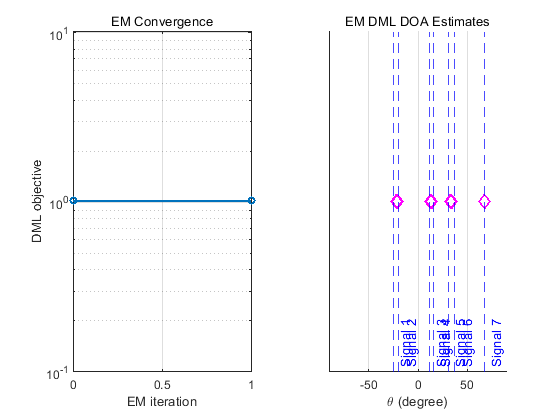

In [78]:
% EM implementation with the same initialization as APA and Gauss--Newton.
assert(exist('MLE_DOA_init', 'var') == 1 && ...
    numel(MLE_DOA_init) == num_sources, ...
    'Run the APA cell first to obtain MLE_DOA_init.');

true_DOA = theta(:).';             % Preserve the simulated DOAs for plotting.
N_em = size(X, 2);
L_em = num_sources;
theta_grid_em = -90:0.1:90;
A_scan_em = steering_vector(theta_grid_em);

EM_DOA = MLE_DOA_init(:).';
A_em = steering_vector(EM_DOA);
EM_S = pinv(A_em)*X;
sigma2_em = norm(X - A_em*EM_S, 'fro')^2/(M*N_em);
sigma2_em = max(real(sigma2_em), eps); % Total noise variance.
sigma2_l_em = sigma2_em/L_em;          % Fixed equal allocation.

max_iter_em = 200;
tol_theta_em = 1e-1;                   % degree
tol_sigma_em = 1e-6;                   % relative variance change
dml_objective_history_em = nan(max_iter_em + 1, 1);
sigma2_history_em = nan(max_iter_em + 1, 1);

P_perp_em = eye(M) - A_em*pinv(A_em);
dml_objective_history_em(1) = ...
    norm(P_perp_em*X, 'fro')^2/N_em;
sigma2_history_em(1) = sigma2_em;
converged_em = false;

for iter_em = 1:max_iter_em
    % Freeze all (k-1)-th estimates before the E-step.
    EM_DOA_prev = EM_DOA;
    EM_S_prev = EM_S;
    sigma2_prev = sigma2_em;
    A_prev = steering_vector(EM_DOA_prev);
    common_residual = X - A_prev*EM_S_prev;

    % E-step: conditional means of all latent source components.
    Yhat_em = complex(zeros(M, N_em, L_em));
    for l = 1:L_em
        Yhat_em(:, :, l) = A_prev(:, l)*EM_S_prev(l, :) ...
            + common_residual/L_em;
    end

    % M-step: independently update each DOA and its source amplitudes.
    component_residual_energy = 0;
    for l = 1:L_em
        Y_l = Yhat_em(:, :, l);
        R_Y_l = Y_l*Y_l'/N_em;

        numerator = real(sum(conj(A_scan_em) .* (R_Y_l*A_scan_em), 1));
        denominator = sum(abs(A_scan_em).^2, 1);
        angle_objective = numerator ./ max(denominator, eps);
        [~, idx] = max(angle_objective);
        EM_DOA(l) = theta_grid_em(idx);

        a_l_new = steering_vector(EM_DOA(l));
        EM_S(l, :) = (a_l_new'*Y_l)/(a_l_new'*a_l_new);
        component_residual_energy = component_residual_energy ...
            + norm(Y_l - a_l_new*EM_S(l, :), 'fro')^2;
    end

    % Update the shared variance and retain equal component allocation.
    sigma2_em = ((L_em - 1)/L_em)*sigma2_prev ...
        + component_residual_energy/(M*N_em);
    sigma2_em = max(real(sigma2_em), eps);
    sigma2_l_em = sigma2_em/L_em;

    % Record the DML objective only for visualization.
    A_em = steering_vector(EM_DOA);
    P_perp_em = eye(M) - A_em*pinv(A_em);
    dml_objective_history_em(iter_em + 1) = ...
        norm(P_perp_em*X, 'fro')^2/N_em;
    sigma2_history_em(iter_em + 1) = sigma2_em;

    % Stop only when both DOAs and the shared variance stabilize.
    % The plotted DML objective is not used as a stopping condition.
    doa_change_em = max(abs(EM_DOA - EM_DOA_prev));
    sigma_change_em = abs(sigma2_em - sigma2_prev) ...
        / max(sigma2_prev, eps);
    if doa_change_em < tol_theta_em && sigma_change_em < tol_sigma_em
        converged_em = true;
        break;
    end
end

[EM_DOA, em_sort_idx] = sort(EM_DOA);
EM_S = EM_S(em_sort_idx, :);
dml_objective_history_em = ...
    dml_objective_history_em(1:iter_em + 1);
sigma2_history_em = sigma2_history_em(1:iter_em + 1);
fprintf('EM estimated angles (degrees), iterations = %d, converged = %d:\n', ...
    iter_em, converged_em);
disp(EM_DOA);
rmse_em = sqrt(mean((EM_DOA(:).' - sort(true_DOA(:).')).^2));
fprintf('True angles (degrees):\n');
disp(sort(true_DOA(:).'));
fprintf('EM RMSE = %.6f degrees\n', rmse_em);
fprintf('EM total noise variance estimate = %.6g\n', sigma2_em);

figure;
tiledlayout(1, 2);
nexttile;
semilogy(0:iter_em, max(dml_objective_history_em, eps), '-o', ...
    'LineWidth', 1.2, 'MarkerSize', 5);
grid on;
xlabel('EM iteration');
ylabel('DML objective');
title('EM Convergence');

nexttile;
hold on;
plot(EM_DOA, zeros(size(EM_DOA)), 'md', ...
    'MarkerSize', 8, 'LineWidth', 1.5);
for ii = 1:numel(true_DOA)
    xline(true_DOA(ii), 'b--', sprintf('Signal %d', ii), ...
        'LineWidth', 1.2, 'LabelVerticalAlignment', 'bottom');
end
grid on;
xlim([-90 90]);
ylim([-1 1]);
xlabel('\theta (degree)');
yticks([]);
title('EM DML DOA Estimates');

## Appendix: Attainability of the TLS Relaxation Bound

Let the corrected augmented matrix be partitioned as

$$
\mathbf{Z}=\begin{bmatrix}\mathbf{Z}_1&\mathbf{Z}_2\end{bmatrix}
\in\mathbb{C}^{(M-1)\times 2K},
$$

where $\mathbf{Z}_1,\mathbf{Z}_2\in\mathbb{C}^{(M-1)\times K}$. The original TLS problem is

$$
\begin{aligned}
p_{\mathrm{TLS}}^{\star}
=\underset{\mathbf{Z},\,\boldsymbol{\Psi}}{\min}\quad
&\left\lVert\hat{\mathbf{Z}}-\mathbf{Z}\right\rVert_F^2\\
\text{s.t.}\quad
&\mathbf{Z}
\begin{bmatrix}
\boldsymbol{\Psi}\\
-\mathbf{I}_K
\end{bmatrix}
=\mathbf{0}.
\end{aligned}
$$

Its rank-relaxed problem is

$$
\begin{aligned}
p_{\mathrm{LR}}^{\star}
=\underset{\mathbf{Z}}{\min}\quad
&\left\lVert\hat{\mathbf{Z}}-\mathbf{Z}\right\rVert_F^2\\
\text{s.t.}\quad
&\operatorname{rank}(\mathbf{Z})\le K.
\end{aligned}
$$

### 1. The relaxed problem provides a lower bound

For every $\boldsymbol{\Psi}$, the matrix

$$
\begin{aligned}
\mathbf{B}(\boldsymbol{\Psi})
&=
\begin{bmatrix}
\boldsymbol{\Psi}\\
-\mathbf{I}_K
\end{bmatrix}
\end{aligned}
$$

has column rank $K$. Therefore, if $\mathbf{Z}\mathbf{B}(\boldsymbol{\Psi})=\mathbf{0}$, the right null space of $\mathbf{Z}$ has dimension at least $K$. Since $\mathbf{Z}$ has $2K$ columns, the rank-nullity theorem gives

$$
\operatorname{rank}(\mathbf{Z})
=2K-\operatorname{nullity}(\mathbf{Z})
\le K.
$$

Hence every matrix feasible for the original TLS problem is feasible for the rank-relaxed problem. The relaxed feasible set is larger, so

$$
\boxed{p_{\mathrm{LR}}^{\star}\le p_{\mathrm{TLS}}^{\star}}.
$$

Thus, $p_{\mathrm{LR}}^{\star}$ is a lower bound on the optimal value of the original TLS problem.

### 2. The Eckart–Young Theorem

Suppose a matrix $\mathbf{A}\in\mathbb{R}^{m\times n}$ has an SVD decomposition

$$
\mathbf{A}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{T}.
$$

Let $k<r=\operatorname{rank}(\mathbf{A})$, let $p=\min(m,n)$, and define the truncated matrix

$$
\mathbf{A}_k=\sum_{i=1}^{k}\sigma_i\mathbf{u}_i\mathbf{v}_i^{T}.
$$

Then, among all matrices $\mathbf{B}$ of rank $k$, the minimum error in the spectral norm is achieved by $\mathbf{A}_k$:

$$
\underset{\operatorname{rank}(\mathbf{B})=k}{\min}
\left\lVert\mathbf{A}-\mathbf{B}\right\rVert_2
=\left\lVert\mathbf{A}-\mathbf{A}_k\right\rVert_2
=\sigma_{k+1}.
$$

The same result holds for the Frobenius norm:

$$
\underset{\operatorname{rank}(\mathbf{B})=k}{\min}
\left\lVert\mathbf{A}-\mathbf{B}\right\rVert_F
=\left\lVert\mathbf{A}-\mathbf{A}_k\right\rVert_F
=\sqrt{\sigma_{k+1}^{2}+\cdots+\sigma_{p}^{2}}.
$$

For the complex-valued relaxed TLS problem, the theorem holds with the transpose replaced by the conjugate transpose. Taking $\mathbf{A}=\hat{\mathbf{Z}}$ and $k=K$, write

$$
\hat{\mathbf{Z}}=\mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^{H},
\qquad
\sigma_1\ge\sigma_2\ge\cdots\ge\sigma_{2K}\ge0.
$$

A relaxed optimizer and its optimal value are therefore

$$
\mathbf{Z}_{\mathrm{LR}}^{\star}
=\mathbf{U}_K\boldsymbol{\Sigma}_K\mathbf{V}_K^{H},
\qquad
p_{\mathrm{LR}}^{\star}
=\sum_{i=K+1}^{2K}\sigma_i^2.
$$

The best rank-$K$ approximation is unique if $\sigma_K>\sigma_{K+1}$.

### 3. Condition under which the lower bound is attained

Partition the selected relaxed optimizer as

$$
\begin{aligned}
\mathbf{Z}_{\mathrm{LR}}^{\star}
&=
\begin{bmatrix}
\mathbf{Z}_{1}^{\star}&\mathbf{Z}_{2}^{\star}
\end{bmatrix}.
\end{aligned}
$$

Assume that its first block has full column rank:

$$
\boxed{\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K}.
$$

Because $\mathbf{Z}_{1}^{\star}$ is a block of $\mathbf{Z}_{\mathrm{LR}}^{\star}$,

$$
\operatorname{rank}(\mathbf{Z}_{\mathrm{LR}}^{\star})
\ge\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K.
$$

The relaxed constraint gives the reverse inequality, so

$$
\operatorname{rank}(\mathbf{Z}_{\mathrm{LR}}^{\star})
=\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K.
$$

Consequently, $\operatorname{col}(\mathbf{Z}_{\mathrm{LR}}^{\star})$ and $\operatorname{col}(\mathbf{Z}_{1}^{\star})$ are nested subspaces with the same dimension. Hence

$$
\operatorname{col}(\mathbf{Z}_{2}^{\star})
\subseteq
\operatorname{col}(\mathbf{Z}_{1}^{\star}),
$$

and there exists a unique matrix

$$
\boldsymbol{\Psi}^{\star}
=\left(\mathbf{Z}_{1}^{\star}\right)^{\dagger}\mathbf{Z}_{2}^{\star}
$$

such that

$$
\mathbf{Z}_{2}^{\star}
=\mathbf{Z}_{1}^{\star}\boldsymbol{\Psi}^{\star}.
$$

Equivalently,

$$
\mathbf{Z}_{\mathrm{LR}}^{\star}
\begin{bmatrix}
\boldsymbol{\Psi}^{\star}\\
-\mathbf{I}_K
\end{bmatrix}
=\mathbf{0}.
$$

Thus, $\mathbf{Z}_{\mathrm{LR}}^{\star}$ is also feasible for the original TLS problem. It follows that

$$
p_{\mathrm{TLS}}^{\star}
\le
\left\lVert\hat{\mathbf{Z}}-\mathbf{Z}_{\mathrm{LR}}^{\star}\right\rVert_F^2
=p_{\mathrm{LR}}^{\star}.
$$

Combining this inequality with the lower-bound inequality gives

$$
\boxed{p_{\mathrm{TLS}}^{\star}=p_{\mathrm{LR}}^{\star}}.
$$

Therefore, when $\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K$, the lower bound supplied by the relaxed problem is attained by the original TLS problem. The two problems have the same optimal value and share the same optimal augmented matrix $\mathbf{Z}_{\mathrm{LR}}^{\star}$; the original problem additionally recovers $\boldsymbol{\Psi}^{\star}$.

### 4. Equivalent nonsingularity condition for V₂₂

Let the right singular vectors be partitioned as

$$
\begin{aligned}
\mathbf{V}
&=
\begin{bmatrix}
\mathbf{V}_{11}&\mathbf{V}_{12}\\
\mathbf{V}_{21}&\mathbf{V}_{22}
\end{bmatrix}
\\
&=
\begin{bmatrix}
\mathbf{V}_K&\mathbf{V}_n
\end{bmatrix},
\\[0.5em]
\mathbf{V}_n
&=
\begin{bmatrix}
\mathbf{V}_{12}\\
\mathbf{V}_{22}
\end{bmatrix},
\end{aligned}
$$

where $\mathbf{V}_n\in\mathbb{C}^{2K\times K}$ spans the right null space of $\mathbf{Z}_{\mathrm{LR}}^{\star}$. Then

$$
\mathbf{Z}_{\mathrm{LR}}^{\star}\mathbf{V}_n=\mathbf{0}.
$$

If $\mathbf{V}_{22}$ is nonsingular, multiplying $\mathbf{V}_n$ by $-\mathbf{V}_{22}^{-1}$ gives

$$
\begin{aligned}
\mathbf{V}_n\left(-\mathbf{V}_{22}^{-1}\right)
&=
\begin{bmatrix}
-\mathbf{V}_{12}\mathbf{V}_{22}^{-1}\\
-\mathbf{I}_K
\end{bmatrix}.
\end{aligned}
$$

Therefore,

$$
\boxed{\boldsymbol{\Psi}_{\mathrm{TLS}}
=-\mathbf{V}_{12}\mathbf{V}_{22}^{-1}}
$$

satisfies the original TLS equality constraint.

Moreover, provided that $\operatorname{rank}(\mathbf{Z}_{\mathrm{LR}}^{\star})=K$, the following two conditions are equivalent:

$$
\boxed{
\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K
\quad\Longleftrightarrow\quad
\mathbf{V}_{22}\text{ is nonsingular}
}.
$$

To see the forward direction, suppose $\mathbf{V}_{22}\mathbf{c}=\mathbf{0}$. From $\mathbf{Z}_{\mathrm{LR}}^{\star}\mathbf{V}_n=\mathbf{0}$, we obtain $\mathbf{Z}_{1}^{\star}\mathbf{V}_{12}\mathbf{c}=\mathbf{0}$. Full column rank of $\mathbf{Z}_{1}^{\star}$ implies $\mathbf{V}_{12}\mathbf{c}=\mathbf{0}$, and hence $\mathbf{V}_n\mathbf{c}=\mathbf{0}$. Since $\mathbf{V}_n$ has full column rank, $\mathbf{c}=\mathbf{0}$, proving that $\mathbf{V}_{22}$ is nonsingular. Conversely, if $\mathbf{V}_{22}$ is nonsingular, the construction above produces $\boldsymbol{\Psi}_{\mathrm{TLS}}$ and gives $\mathbf{Z}_{2}^{\star}=\mathbf{Z}_{1}^{\star}\boldsymbol{\Psi}_{\mathrm{TLS}}$. Hence $\operatorname{rank}(\mathbf{Z}_{\mathrm{LR}}^{\star})=\operatorname{rank}(\mathbf{Z}_{1}^{\star})$. Under the standing assumption $\operatorname{rank}(\mathbf{Z}_{\mathrm{LR}}^{\star})=K$, it follows that $\operatorname{rank}(\mathbf{Z}_{1}^{\star})=K$. 
